In [2]:

# Your dictionary of scores
real_privacy_scores = {
    'a7_fingerprint': 0.53,
    'a8_signature': 0.95,
    'a110_nudity_all': 0.85,
    'a111_name_all': 0.92,
    'a24_birth_date': 0.8,
    'a26_handwriting': 0.85,
    'a30_credit_card': 0.98,
    'a31_passport': 0.98,
    'a32_drivers_license': 1.0,
    'a33_student_id': 0.99,
    'a35_mail': 0.7,
    'a37_receipt': 0.8,
    'a38_ticket': 0.9,
    'a43_medicine': 0.87,
    'a49_phone': 0.6,
    'location': 0.58,
    'a82_date_time': 0.47,
    'a90_email': 0.74,
    'a103_license_plate_all': 0.34,
    'a105_face_all': 0.38,
    'a109_person_body': 0.3
}

# Prettify names
name_map = {
    'a7_fingerprint': "Fingerprint",
    'a8_signature': "Signature",
    'a110_nudity_all': "Nudity",
    'a111_name_all': "Name",
    'a24_birth_date': "Birth date",
    'a26_handwriting': "Handwriting",
    'a30_credit_card': "Credit card",
    'a31_passport': "Passport",
    'a32_drivers_license': "Driver's license",
    'a33_student_id': "Student ID",
    'a35_mail': "Mail",
    'a37_receipt': "Receipt",
    'a38_ticket': "Ticket",
    'a43_medicine': "Medicine",
    'a49_phone': "Phone",
    'location': "Location",
    'a82_date_time': "Date/Time",
    'a90_email': "Email",
    'a103_license_plate_all': "License plate",
    'a105_face_all': "Face",
    'a109_person_body': "Person (body)"
}

sorted_scores = sorted(
    [(name_map.get(k, k), v) for k, v in real_privacy_scores.items()],
    key=lambda x: x[1]
)

# Separate names and values
classes, scores = zip(*sorted_scores)

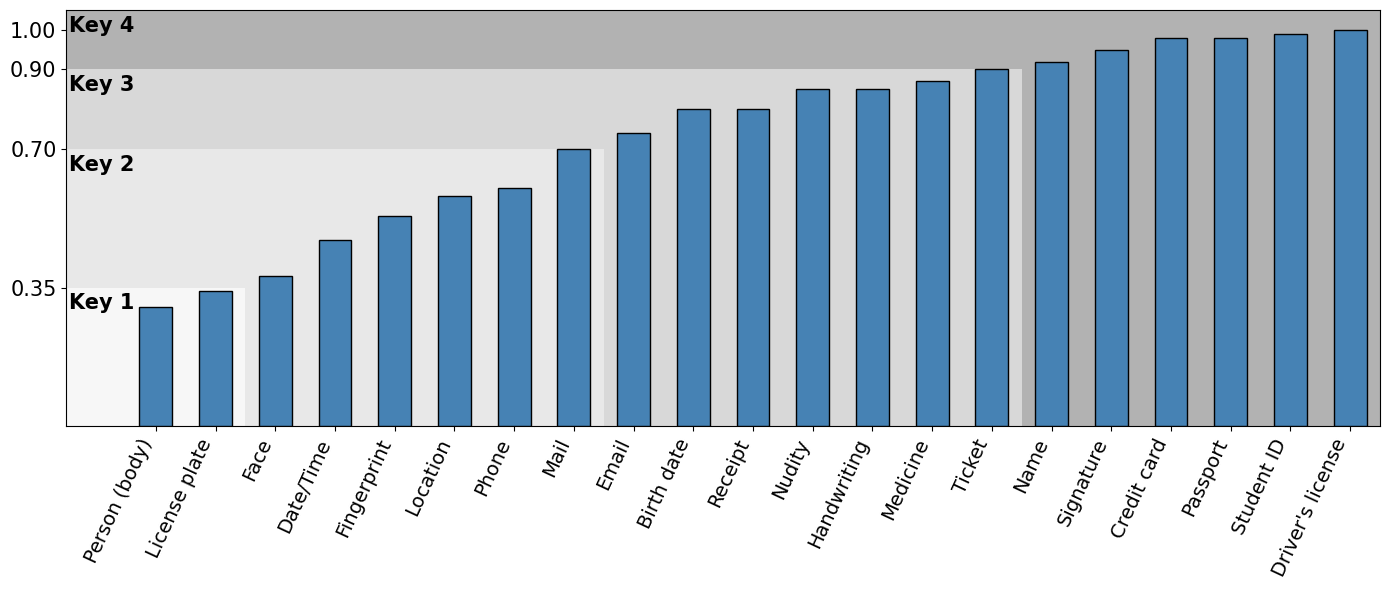

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Assumes classes, scores are sorted ascending
plt.figure(figsize=(14, 6))  # wider figure

# Thicker vertical bars for classes
bars = plt.bar(classes, scores, color="steelblue", edgecolor="black", width=0.55, zorder=3)   # dark gray / charcoal

ax = plt.gca()
plt.ylim(0, 1.05)  # ensure ceiling
top_y = ax.get_ylim()[1]

keys = [
    ("Key 1", 0.35),
    ("Key 2", 0.70),
    ("Key 3", 0.90),
    ("Key 4", 1.00),
]

# light -> dark red
shades = ["#f2f2f2", "#d9d9d9", "#bfbfbf", "#808080"]

# layout: bars are centered at x = 0..n-1, first bar's left edge is at -0.5
gap_right = -0.5
gap_width = 1.0
gap_left  = gap_right - gap_width

def last_unlocked_index(scores, t):
    idx = -1
    for i, s in enumerate(scores):
        if s <= t:
            idx = i
        else:
            break
    return idx

prev_t = 0.0
prev_last_idx = -1

for i, ((key_name, t), color) in enumerate(zip(keys, shades)):
    last_idx = last_unlocked_index(scores, t)
    band_top = top_y if i == len(keys) - 1 else t
    height = max(0.0, band_top - prev_t)

    if last_idx >= 0 and height > 0:
        # main band
        ax.add_patch(Rectangle(
            (gap_right, prev_t), last_idx + 1, height,
            facecolor=color, edgecolor="none", alpha=0.6, zorder=1
        ))
        # gap fill
        ax.add_patch(Rectangle(
            (gap_left, prev_t), gap_width, height,
            facecolor=color, edgecolor="none", alpha=0.6, zorder=1
        ))
        # bold black key label
        ax.text(
            gap_left + 0.05, prev_t + height - 0.015,
            key_name,
            va="top", ha="left", fontsize=15, fontweight="bold",
            color="black", zorder=4
        )

    # extension band
    if last_idx > prev_last_idx and prev_t > 0:
        ax.add_patch(Rectangle(
            (prev_last_idx + 0.5, 0.0),
            last_idx - prev_last_idx, prev_t,
            facecolor=color, edgecolor="none", alpha=0.6, zorder=1
        ))

    prev_t = max(prev_t, t)
    prev_last_idx = max(prev_last_idx, last_idx)

# rotate x labels so they don’t overlap
plt.xticks(rotation=65, ha="right", fontsize= 14)

# set custom y ticks: all keys except Key4 (1.0 already exists)
yticks = [val for _, val in keys[:-1]] + [1.0]
plt.yticks(yticks, fontsize=15)

# expand xlim to include gap
plt.xlim(gap_left, len(classes) - 0.5)

plt.tight_layout()
plt.show()


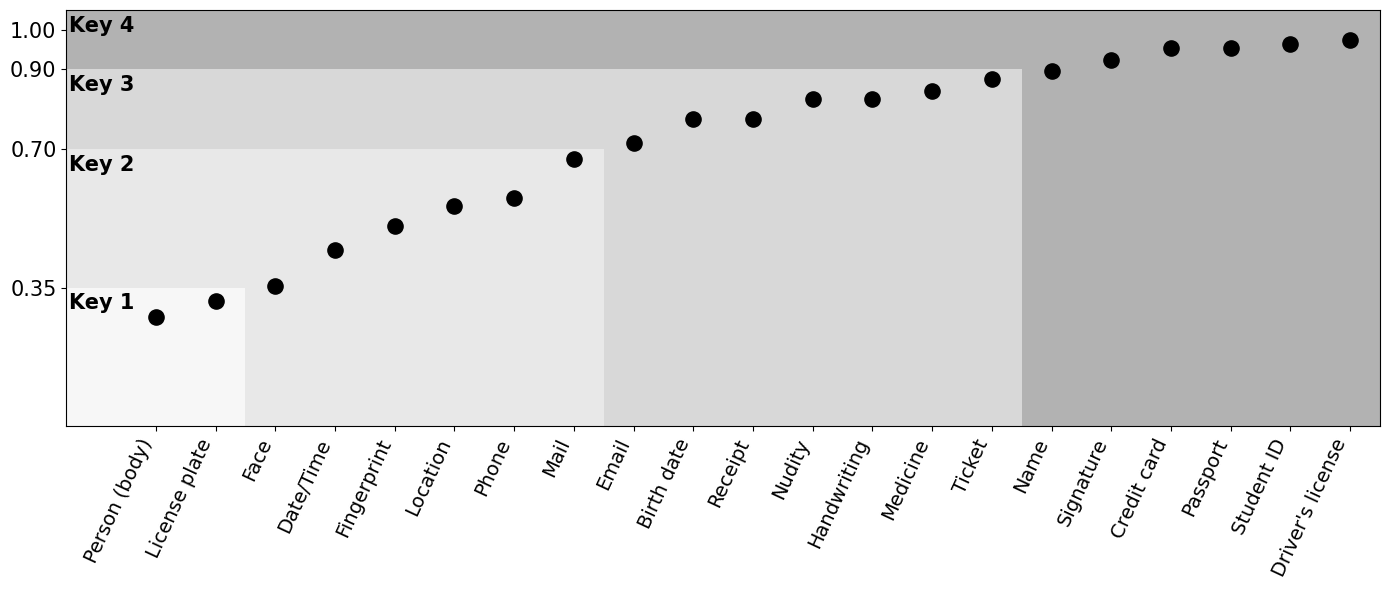

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# Assumes classes, scores are sorted ascending
plt.figure(figsize=(14, 6))  # wider figure

ax = plt.gca()
plt.ylim(0, 1.05)  # ensure ceiling
top_y = ax.get_ylim()[1]

marker_size = 120  # same as your scatter
for i, s in enumerate(scores):
    # Convert marker size (points) to height in data coords
    pixel_size = np.sqrt(marker_size)  # marker size in points
    pixel_size = ax.transData.inverted().transform(
        ax.transData.transform((0, s)) + (0, pixel_size)
    )[1] - s

    adjusted_y = s - pixel_size  # shift center down
    plt.scatter(i, adjusted_y, color="black", edgecolor="black",
                marker="o", s=marker_size, zorder=3)

# Add dashed vertical lines from x ticks up to markers
#for i, s in enumerate(scores):
#    ax.vlines(i, 0, s, linestyles="dashed", colors="black", alpha=0.7, zorder=2)

keys = [
    ("Key 1", 0.35),
    ("Key 2", 0.70),
    ("Key 3", 0.90),
    ("Key 4", 1.00),
]

# light -> dark red
shades = ["#f2f2f2", "#d9d9d9", "#bfbfbf", "#808080"]

# layout: markers are centered at x = 0..n-1
gap_right = -0.5
gap_width = 1.0
gap_left  = gap_right - gap_width

def last_unlocked_index(scores, t):
    idx = -1
    for i, s in enumerate(scores):
        if s <= t:
            idx = i
        else:
            break
    return idx

prev_t = 0.0
prev_last_idx = -1

for i, ((key_name, t), color) in enumerate(zip(keys, shades)):
    last_idx = last_unlocked_index(scores, t)
    band_top = top_y if i == len(keys) - 1 else t
    height = max(0.0, band_top - prev_t)

    if last_idx >= 0 and height > 0:
        # main band
        ax.add_patch(Rectangle(
            (gap_right, prev_t), last_idx + 1, height,
            facecolor=color, edgecolor="none", alpha=0.6, zorder=1
        ))
        # gap fill
        ax.add_patch(Rectangle(
            (gap_left, prev_t), gap_width, height,
            facecolor=color, edgecolor="none", alpha=0.6, zorder=1
        ))
        # bold black key label
        ax.text(
            gap_left + 0.05, prev_t + height - 0.015,
            key_name,
            va="top", ha="left", fontsize=15, fontweight="bold",
            color="black", zorder=4
        )

    # extension band
    if last_idx > prev_last_idx and prev_t > 0:
        ax.add_patch(Rectangle(
            (prev_last_idx + 0.5, 0.0),
            last_idx - prev_last_idx, prev_t,
            facecolor=color, edgecolor="none", alpha=0.6, zorder=1
        ))

    prev_t = max(prev_t, t)
    prev_last_idx = max(prev_last_idx, last_idx)

# rotate x labels so they don’t overlap
plt.xticks(range(len(classes)), classes, rotation=65, ha="right", fontsize=14)

# set custom y ticks: all keys except Key4 (1.0 already exists)
yticks = [val for _, val in keys[:-1]] + [1.0]
plt.yticks(yticks, fontsize=15)

# expand xlim to include gap
plt.xlim(gap_left, len(classes) - 0.5)

plt.tight_layout()
plt.show()


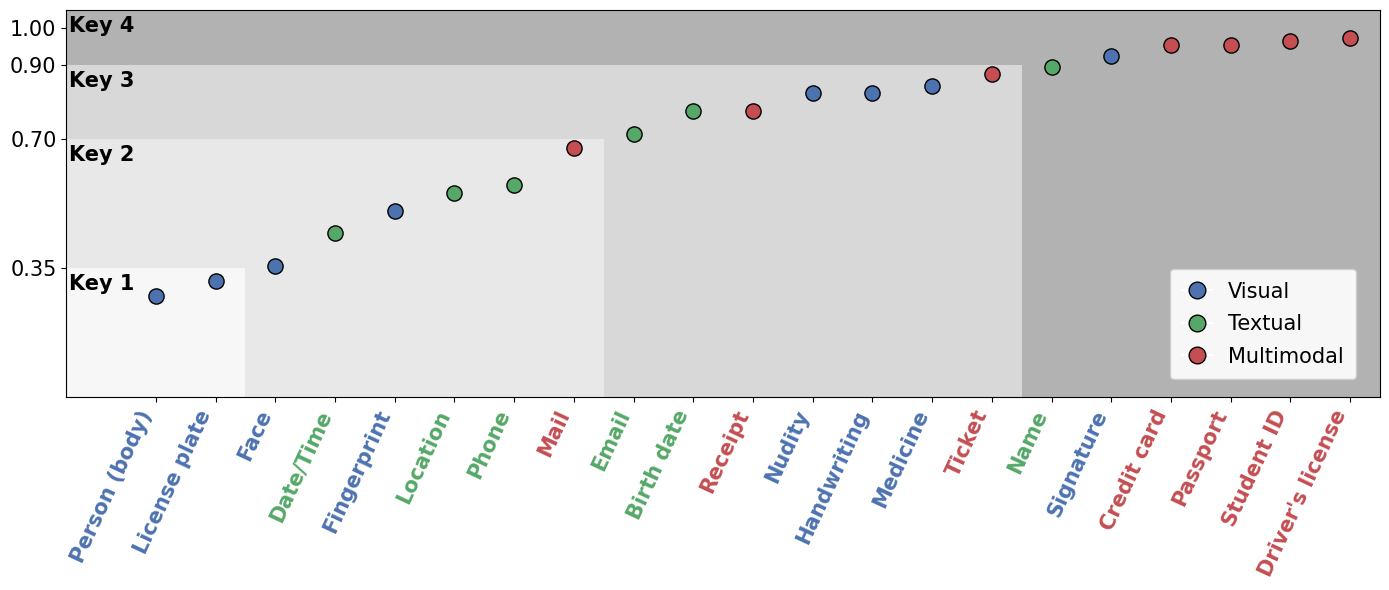

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# Your dictionary of scores
real_privacy_scores = {
    'a7_fingerprint': 0.53,
    'a8_signature': 0.95,
    'a110_nudity_all': 0.85,
    'a111_name_all': 0.92,
    'a24_birth_date': 0.8,
    'a26_handwriting': 0.85,
    'a30_credit_card': 0.98,
    'a31_passport': 0.98,
    'a32_drivers_license': 1.0,
    'a33_student_id': 0.99,
    'a35_mail': 0.7,
    'a37_receipt': 0.8,
    'a38_ticket': 0.9,
    'a43_medicine': 0.87,
    'a49_phone': 0.6,
    'location': 0.58,
    'a82_date_time': 0.47,
    'a90_email': 0.74,
    'a103_license_plate_all': 0.34,
    'a105_face_all': 0.38,
    'a109_person_body': 0.3
}

# Prettify names
name_map = {
    'a7_fingerprint': "Fingerprint",
    'a8_signature': "Signature",
    'a110_nudity_all': "Nudity",
    'a111_name_all': "Name",
    'a24_birth_date': "Birth date",
    'a26_handwriting': "Handwriting",
    'a30_credit_card': "Credit card",
    'a31_passport': "Passport",
    'a32_drivers_license': "Driver's license",
    'a33_student_id': "Student ID",
    'a35_mail': "Mail",
    'a37_receipt': "Receipt",
    'a38_ticket': "Ticket",
    'a43_medicine': "Medicine",
    'a49_phone': "Phone",
    'location': "Location",
    'a82_date_time': "Date/Time",
    'a90_email': "Email",
    'a103_license_plate_all': "License plate",
    'a105_face_all': "Face",
    'a109_person_body': "Person (body)"
}

# Sort scores ascending
sorted_scores = sorted(
    [(name_map.get(k, k), v, k) for k, v in real_privacy_scores.items()],
    key=lambda x: x[1]
)

# Separate names and values
classes, scores, keys = zip(*sorted_scores)

# Define groups
group_A = {
    'a7_fingerprint', 'a8_signature', 'a110_nudity_all',
    'a26_handwriting', 'a43_medicine',
    'a103_license_plate_all', 'a105_face_all', 'a109_person_body'
}
group_B = {
    'a111_name_all', 'a24_birth_date', 'a82_date_time',
    'a90_email', 'a49_phone', 'location'
}
group_C = {
    'a30_credit_card', 'a31_passport', 'a32_drivers_license',
    'a33_student_id', 'a35_mail', 'a37_receipt', "a38_ticket"
}
COLOR_A = "#4C72B0"  # Visual
COLOR_B = "#55A868"  # Textual
COLOR_C = "#C44E52"  # Multimodal
# Assign colors for groups
color_map = {}
for k in group_A: color_map[name_map[k]] = "#4C72B0"   # blue
for k in group_B: color_map[name_map[k]] = "#55A868"   # green
for k in group_C: color_map[name_map[k]] = "#C44E52"   # red

# Plot setup
plt.figure(figsize=(14, 6))
ax = plt.gca()
plt.ylim(0, 1.05)
top_y = ax.get_ylim()[1]

# Scatter plotting with group colors
marker_size = 120
for i, (cls, s) in enumerate(zip(classes, scores)):
    pixel_size = np.sqrt(marker_size)
    pixel_size = ax.transData.inverted().transform(
        ax.transData.transform((0, s)) + (0, pixel_size)
    )[1] - s

    adjusted_y = s - pixel_size
    plt.scatter(
        i, adjusted_y,
        color=color_map.get(cls, "black"),
        edgecolor="black",
        marker="o", s=marker_size, zorder=3
    )

# Key thresholds
keys_thresholds = [
    ("Key 1", 0.35),
    ("Key 2", 0.70),
    ("Key 3", 0.90),
    ("Key 4", 1.00),
]

# Lighter grayscale shades
shades = ["#f2f2f2", "#d9d9d9", "#bfbfbf", "#808080"]

# Layout for key bands
gap_right = -0.5
gap_width = 1.0
gap_left  = gap_right - gap_width

def last_unlocked_index(scores, t):
    idx = -1
    for i, s in enumerate(scores):
        if s <= t:
            idx = i
        else:
            break
    return idx

prev_t = 0.0
prev_last_idx = -1

for i, ((key_name, t), color) in enumerate(zip(keys_thresholds, shades)):
    last_idx = last_unlocked_index(scores, t)
    band_top = top_y if i == len(keys_thresholds) - 1 else t
    height = max(0.0, band_top - prev_t)

    if last_idx >= 0 and height > 0:
        ax.add_patch(Rectangle(
            (gap_right, prev_t), last_idx + 1, height,
            facecolor=color, edgecolor="none", alpha=0.6, zorder=1
        ))
        ax.add_patch(Rectangle(
            (gap_left, prev_t), gap_width, height,
            facecolor=color, edgecolor="none", alpha=0.6, zorder=1
        ))
        ax.text(
            gap_left + 0.05, prev_t + height - 0.015,
            key_name,
            va="top", ha="left", fontsize=15, fontweight="bold",
            color="black", zorder=4
        )

    if last_idx > prev_last_idx and prev_t > 0:
        ax.add_patch(Rectangle(
            (prev_last_idx + 0.5, 0.0),
            last_idx - prev_last_idx, prev_t,
            facecolor=color, edgecolor="none", alpha=0.6, zorder=1
        ))

    prev_t = max(prev_t, t)
    prev_last_idx = max(prev_last_idx, last_idx)

# Rotate x labels
plt.xticks(range(len(classes)), classes, rotation=65, ha="right", fontsize=15)
# Color x tick labels according to group
for label in ax.get_xticklabels():
    text = label.get_text()
    if text in color_map:
        label.set_color(color_map[text])
        label.set_fontweight("bold")

# Custom y ticks
yticks = [val for _, val in keys_thresholds[:-1]] + [1.0]
plt.yticks(yticks, fontsize=15)

# Expand xlim to include gap
plt.xlim(gap_left, len(classes) - 0.5)

# Legend: use group names (Visual, Textual, Multimodal), bottom-left, bigger
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Visual',
               markerfacecolor=COLOR_A, markeredgecolor="black", markersize=12),
    plt.Line2D([0], [0], marker='o', color='w', label='Textual',
               markerfacecolor=COLOR_B, markeredgecolor="black", markersize=12),
    plt.Line2D([0], [0], marker='o', color='w', label='Multimodal',
               markerfacecolor=COLOR_C, markeredgecolor="black", markersize=12),
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    bbox_to_anchor=(0.99, 0.02),  # push to bottom-right
    fontsize=15,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    borderpad=0.6,
    labelspacing=0.6,
    handlelength=1.4
)

plt.tight_layout()
plt.show()


# Imports & Functions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import json
from collections import Counter
import matplotlib.pyplot as plt
from itertools import combinations

In [ ]:
def plot_label_frequencies(label_counter):
    # Sort labels by count
    sorted_labels = label_counter.most_common()
    labels, counts = zip(*sorted_labels)

    # Plot
    plt.figure(figsize=(8, len(labels) * 0.3))
    bars = plt.barh(range(len(labels)), counts, color='skyblue')
    plt.yticks(range(len(labels)), labels, fontsize=8)
    plt.xticks(fontsize=8)
    plt.title("Label Frequency", fontsize=10)
    plt.xlabel("Count", fontsize=9)
    plt.ylabel("Label", fontsize=9)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
def get_top_attr_combinations(all_annotations, n=2, min_count=1, max_count = 10000):
    """
    Get the most common attribute combinations of size `n` from the annotation data.

    Args:
        all_annotations (dict): Dictionary of all image annotations.
        n (int): Size of the attribute combinations (e.g., 2 for pairs, 3 for triples).
        min_count (int): Minimum frequency threshold to include a combination.
def color_segmented_area(image_path, segmentation):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = segmentation['size']

    rle = {
        "counts": segmentation["counts"].encode('utf-8'),
        "size": segmentation["size"]
    }
    mask = mask_utils.decode(rle).astype(bool)

    # Color the area
    result = img.copy()
    result[mask] = [0, 0, 0]

    # Draw contour
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(result, contours, -1, (255, 0, 0), thickness=3)

    plt.figure(figsize=(10, 10))
    plt.imshow(result)
    plt.axis('off')
    plt.title("Colored Segment with Outline")
    plt.show()
    Returns:
        List of tuples: [((attr1, attr2, ...), count), ...] sorted in descending order of count.
    """
    combo_counter = Counter()

    for image_data in all_annotations.values():
        attr_ids = [attr['attr_id'] for attr in image_data.get('attributes', [])]
        unique_attrs = set(attr_ids)
        if len(unique_attrs) >= n:
            combos = combinations(sorted(unique_attrs), n)
            combo_counter.update(combos)

    # Filter and sort results
    filtered = [(combo, count) for combo, count in combo_counter.items() if count >= min_count and count < max_count]
    return sorted(filtered, key=lambda x: x[1], reverse=True)


In [ ]:
def plot_attr_combinations_bar(attr_combos, title="Top Attribute Combinations", max_bars=30):
    """
    Plots a horizontal bar chart of the most frequent attribute combinations.

    Args:
        attr_combos (list): List of ((attr1, attr2, ...), count) tuples.
        title (str): Title of the plot.
        max_bars (int): Max number of bars to show.
    """
    if not attr_combos:
        print("No data to plot.")
        return

    # Trim to top N
    attr_combos = attr_combos[:max_bars]

    labels = [' + '.join(combo) for combo, _ in attr_combos]
    counts = [count for _, count in attr_combos]

    plt.figure(figsize=(14, 6))
    plt.barh(labels, counts)
    plt.xlabel("Number of Co-occurrences")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_top_pairs_pie(top_pairs):
    labels = [f"{a} + {b}" for (a, b), _ in top_pairs]
    counts = [count for _, count in top_pairs]

    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8})
    plt.title("Top Attribute Pairs Distribution", fontsize=12)
    plt.tight_layout()
    plt.show()


In [ ]:
def get_combos_with_label(all_annotations, target_label, combo_size=2, top_n=20):
    combo_counter = Counter()

    for image_data in all_annotations.values():
        attr_ids = [attr['attr_id'] for attr in image_data.get('attributes', [])]
        unique_attrs = set(attr_ids)

        if target_label in unique_attrs and len(unique_attrs) >= combo_size:
            for combo in combinations(sorted(unique_attrs), combo_size):
                if target_label in combo:
                    combo_counter[combo] += 1

    return combo_counter.most_common(top_n)


In [ ]:
def get_combos_with_label_inclusive(all_annotations, target_label, combo_size=2, top_n=20):
    combo_counter = Counter()

    for image_data in all_annotations.values():
        attr_ids = [attr['attr_id'] for attr in image_data.get('attributes', [])]

        if attr_ids.count(target_label) >= 1 and len(attr_ids) >= combo_size:
            for combo in combinations(sorted(attr_ids), combo_size):
                if target_label in combo:
                    combo_counter[combo] += 1

    return combo_counter.most_common(top_n)

In [ ]:
def visualize_label_combos(combo_list, title="Co-occurrence with Label"):
    if not combo_list:
        print("No combinations to display.")
        return

    combos, counts = zip(*combo_list)
    labels = [' + '.join(combo) for combo in combos]

    plt.figure(figsize=(8, len(labels) * 0.3))
    bars = plt.barh(range(len(labels)), counts, color='skyblue')
    plt.yticks(range(len(labels)), labels, fontsize=8)
    plt.xticks(fontsize=8)
    plt.title(title, fontsize=10)
    plt.xlabel("Count", fontsize=9)
    plt.ylabel("Combination", fontsize=9)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
def remove_images_with_classes(annotations_data, excluded_classes):
    """
    Removes entire images from the dataset if any of their attributes match the excluded classes.

    :param annotations_data: Dictionary containing annotations per image.
    :param excluded_classes: List of attr_id values (e.g., ["a32_drivers_license"]) to exclude.
    :return: Filtered annotations_data with selected images removed.
    """
    filtered_data = copy.deepcopy(annotations_data)

    images_to_remove = []
    for image_id, image in filtered_data.items():
        for attr in image.get("attributes", []):
            if attr["attr_id"] in excluded_classes:
                images_to_remove.append(image_id)
                break  # No need to check further attributes

    for image_id in images_to_remove:
        del filtered_data[image_id]

    return filtered_data

# Analysis

In [ ]:
file_paths = [
    "/content/drive/MyDrive/nokia/annotations.json",
    "/content/drive/MyDrive/nokia/annotations2.json",
    "/content/drive/MyDrive/nokia/annotations3.json"
]

# Merge annotations
all_annotations = {}

for path in file_paths:
    with open(path, 'r') as f:
        data = json.load(f)
        all_annotations.update(data.get('annotations', {}))

print(f"Total images: {len(all_annotations)}")

Total images: 8473


In [ ]:
# List of target attribute IDs
target_attr_ids = {
    "a30_credit_card",
    "a31_passport",
    "a32_drivers_license",
    "a33_student_id",
    "a35_mail",
    "a37_receipt",
    "a38_ticket"
}

# Count how many images contain at least one of the target attributes
count = 0

for image_id, image_data in all_annotations.items():
    for attr in image_data.get("attributes", []):
        if attr.get("attr_id") in target_attr_ids:
            count += 1
            break  # No need to check other attributes for this image

print(f"Number of images with at least one target attribute: {count}")


Number of images with at least one target attribute: 1356


In [ ]:
# Define the target attributes
target_attr_ids = {
    "a30_credit_card",
    "a31_passport",
    "a32_drivers_license",
    "a33_student_id",
    "a35_mail",
    "a37_receipt",
    "a38_ticket"
}

# Initialize counters
image_counts = {attr_id: 0 for attr_id in target_attr_ids}
instance_counts = {attr_id: 0 for attr_id in target_attr_ids}

# Iterate over all images
for image_data in all_annotations.values():
    seen_in_image = set()
    for attr in image_data.get("attributes", []):
        attr_id = attr.get("attr_id")
        if attr_id in target_attr_ids:
            instance_counts[attr_id] += 1
            seen_in_image.add(attr_id)
    for attr_id in seen_in_image:
        image_counts[attr_id] += 1

# Print results
print("Attribute ID         | # Images Appeared In | # Total Instances")
print("-" * 60)
for attr_id in sorted(target_attr_ids):
    print(f"{attr_id:<20} | {image_counts[attr_id]:>20} | {instance_counts[attr_id]:>18}")


Attribute ID         | # Images Appeared In | # Total Instances
------------------------------------------------------------
a30_credit_card      |                   94 |                271
a31_passport         |                  253 |                300
a32_drivers_license  |                   65 |                 76
a33_student_id       |                   67 |                 86
a35_mail             |                  157 |                179
a37_receipt          |                  218 |                270
a38_ticket           |                  537 |                945


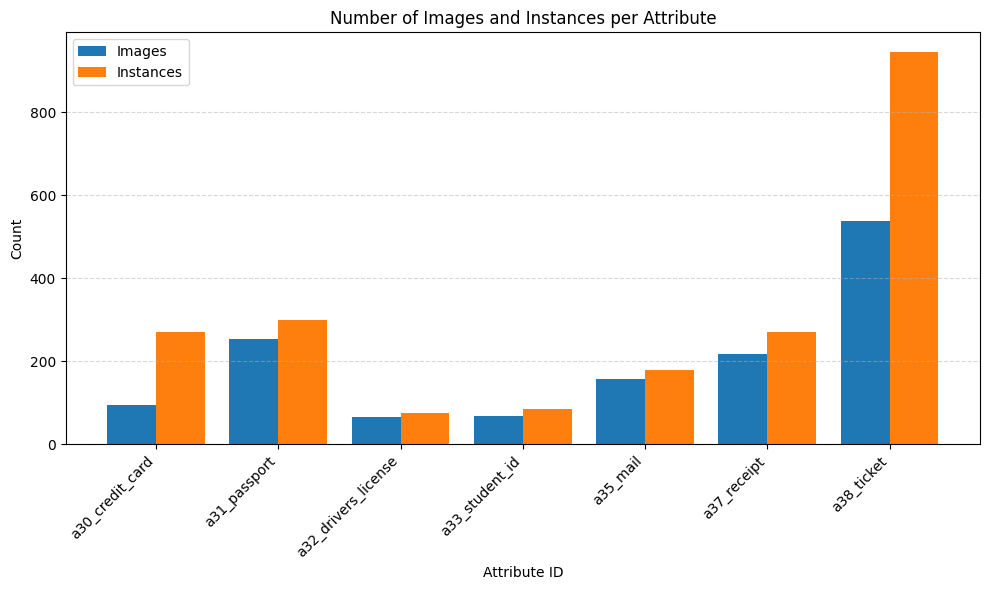

In [ ]:
import matplotlib.pyplot as plt

# Define target attributes
target_attr_ids = {
    "a30_credit_card",
    "a31_passport",
    "a32_drivers_license",
    "a33_student_id",
    "a35_mail",
    "a37_receipt",
    "a38_ticket"
}

# Initialize counts
image_counts = {attr_id: 0 for attr_id in target_attr_ids}
instance_counts = {attr_id: 0 for attr_id in target_attr_ids}

# Populate counts
for image_data in all_annotations.values():
    seen_in_image = set()
    for attr in image_data.get("attributes", []):
        attr_id = attr.get("attr_id")
        if attr_id in target_attr_ids:
            instance_counts[attr_id] += 1
            seen_in_image.add(attr_id)
    for attr_id in seen_in_image:
        image_counts[attr_id] += 1

# Prepare data for plotting
attributes = sorted(target_attr_ids)
image_vals = [image_counts[attr] for attr in attributes]
instance_vals = [instance_counts[attr] for attr in attributes]

x = range(len(attributes))
bar_width = 0.4

# Plot
plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], image_vals, width=bar_width, label='Images')
plt.bar([i + bar_width/2 for i in x], instance_vals, width=bar_width, label='Instances')

# Labels and formatting
plt.xticks(ticks=x, labels=attributes, rotation=45, ha='right')
plt.xlabel("Attribute ID")
plt.ylabel("Count")
plt.title("Number of Images and Instances per Attribute")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


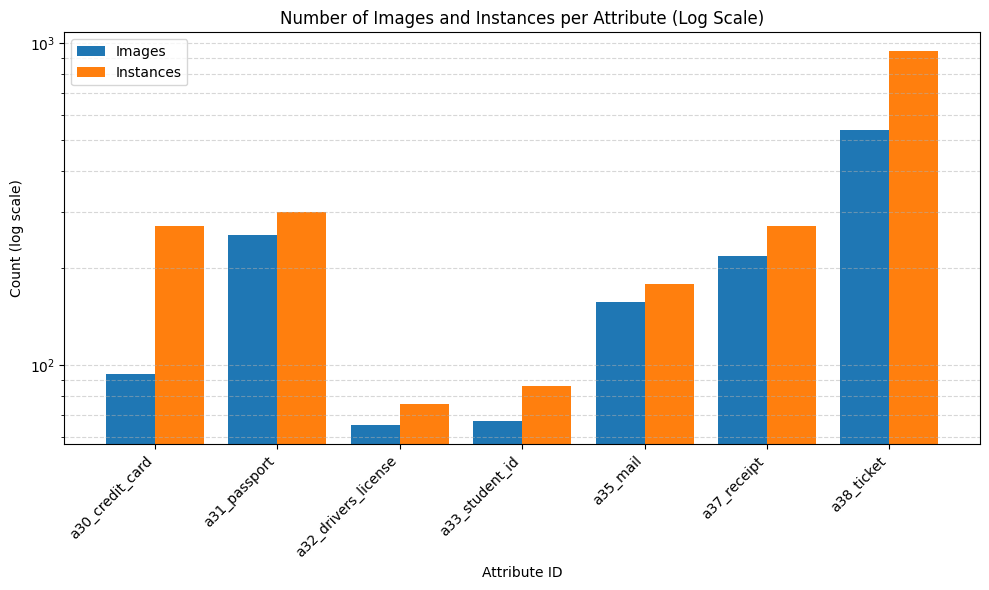

In [ ]:
# Plot
plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], image_vals, width=bar_width, label='Images')
plt.bar([i + bar_width/2 for i in x], instance_vals, width=bar_width, label='Instances')

# Labels and formatting
plt.xticks(ticks=x, labels=attributes, rotation=45, ha='right')
plt.xlabel("Attribute ID")
plt.ylabel("Count (log scale)")
plt.title("Number of Images and Instances per Attribute (Log Scale)")
plt.yscale('log')  # ← LOG SCALE HERE
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5, which='both')

plt.show()


In [ ]:
all_annotations["2017_73753182"]

{'image_path': 'images/test2017/2017_73753182.jpg',
 'image_width': 1290,
 'image_id': '2017_73753182',
 'image_height': 615,
 'attributes': [{'segmentation': {'counts': 'gWV13mb07J6I8I6J6I7J6I7J6I8I6J6I7J6I7J7H7J6J6I7J6I7J7H7J6J6I7J6I7J7H7J6J6I7J6I8I6I7J6J6I7J6I8I6J6I7J6I7J7H7J6J6I7J6I7J7H7J6J6I7M301O01O0000000001O01O00000000010O0000000001O01O00000000010O00000000010O0000000000010O00000000010O0000000000010O00000000010O000000000010O0000000000010O00000000010O0000000000010O00000000010O0000000001O01O00000000010O0000000001O01O00000000010O0000000001O01O00000001O0001O00000001O01O00000001O0001O00000001O01O00000001O0001O000001O0001O00000001O0001O000001O0001O00000001O0001O000001O000001O0001O000001O000001O000001O0001O000001O000001O000001O0001O000001O0001O00000001O0001O000001O0001O00000001O0001O00000001O01O00000001O01O0000000001O01O00000001O01O0000000001O01O00000001O01O00000000010O0000000001O01O00000000010O0000000000010O00000000010O000000000010O000000000010O000000000010O000000000010O000000000010O0

In [ ]:
import copy

def get_merged_person_annotations(annotations_data):
    new_annotations = copy.deepcopy(annotations_data)

    for image in new_annotations.values():
        for attr in image.get("attributes", []):
            if attr["attr_id"] in ["a109_person_body", "a105_face_all"]:
                attr["attr_id"] = "person"

    return new_annotations


In [ ]:
merged_annotations = get_merged_person_annotations(all_annotations)

In [ ]:
# Count how many times each attribute ID appears
label_counter = Counter()

for image_data in merged_annotations.values():
    attr_ids = [attr['attr_id'] for attr in image_data.get('attributes', [])]
    label_counter.update(attr_ids)

# Sort by count in descending order
sorted_labels = label_counter.most_common()

# Print results
print("Attribute Labels Sorted by Frequency:")
for label, count in sorted_labels:
    print(f"{label}: {count}")


Attribute Labels Sorted by Frequency:
person: 22167
a82_date_time: 6997
a111_name_all: 4153
a106_address_current_all: 4152
a26_handwriting: 2421
a73_landmark: 1806
a38_ticket: 945
a110_nudity_all: 910
a85_username: 770
a108_license_plate_all: 722
a8_signature: 511
a43_medicine: 425
a49_phone: 344
a31_passport: 300
a30_credit_card: 271
a37_receipt: 270
a107_address_home_all: 261
a18_ethnic_clothing: 259
a39_disability_physical: 179
a35_mail: 179
a7_fingerprint: 157
a24_birth_date: 156
a90_email: 147
a70_education_history: 138
a33_student_id: 86
a32_drivers_license: 76
a29_ausweis: 44


In [ ]:
excluded = ["a49_phone","a38_ticket","a31_passport","a30_credit_card","a37_receipt","a35_mail", "a33_student_id","a32_drivers_license", "a29_ausweis"]
filtered_annotations = remove_images_with_classes(merged_annotations, excluded)
label_counter2 = Counter()

for image_data in filtered_annotations.values():
    attr_ids = [attr['attr_id'] for attr in image_data.get('attributes', [])]
    label_counter2.update(attr_ids)

# Sort by count in descending order
sorted_labels = label_counter2.most_common()

# Print results
print("Attribute Labels Sorted by Frequency:")
for label, count in sorted_labels:
    print(f"{label}: {count}")

print(len(filtered_annotations.values()))

Attribute Labels Sorted by Frequency:
person: 21260
a82_date_time: 3323
a111_name_all: 3188
a106_address_current_all: 2206
a26_handwriting: 1322
a73_landmark: 1061
a110_nudity_all: 905
a85_username: 761
a108_license_plate_all: 708
a43_medicine: 390
a18_ethnic_clothing: 258
a8_signature: 180
a39_disability_physical: 179
a7_fingerprint: 150
a70_education_history: 133
a90_email: 107
a107_address_home_all: 92
a24_birth_date: 44
6955


## General Occurences

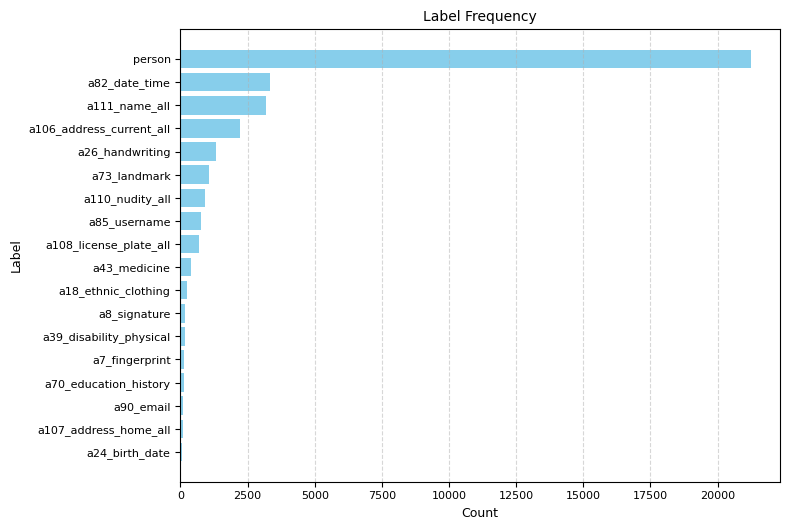

In [ ]:
plot_label_frequencies(label_counter2)

In [ ]:
# Get top attribute pairs that occur at least 100 times
top_pairs = get_top_attr_combinations(filtered_annotations, n=2, min_count=100, max_count=100000)
top_pairs

[(('a110_nudity_all', 'person'), 621),
 (('a106_address_current_all', 'a82_date_time'), 286),
 (('a111_name_all', 'a82_date_time'), 286),
 (('a106_address_current_all', 'person'), 268),
 (('a111_name_all', 'person'), 250),
 (('a82_date_time', 'person'), 229),
 (('a106_address_current_all', 'a111_name_all'), 208),
 (('a108_license_plate_all', 'person'), 173),
 (('a111_name_all', 'a26_handwriting'), 168),
 (('a26_handwriting', 'a82_date_time'), 156),
 (('a106_address_current_all', 'a73_landmark'), 144),
 (('a73_landmark', 'person'), 130),
 (('a18_ethnic_clothing', 'person'), 130)]

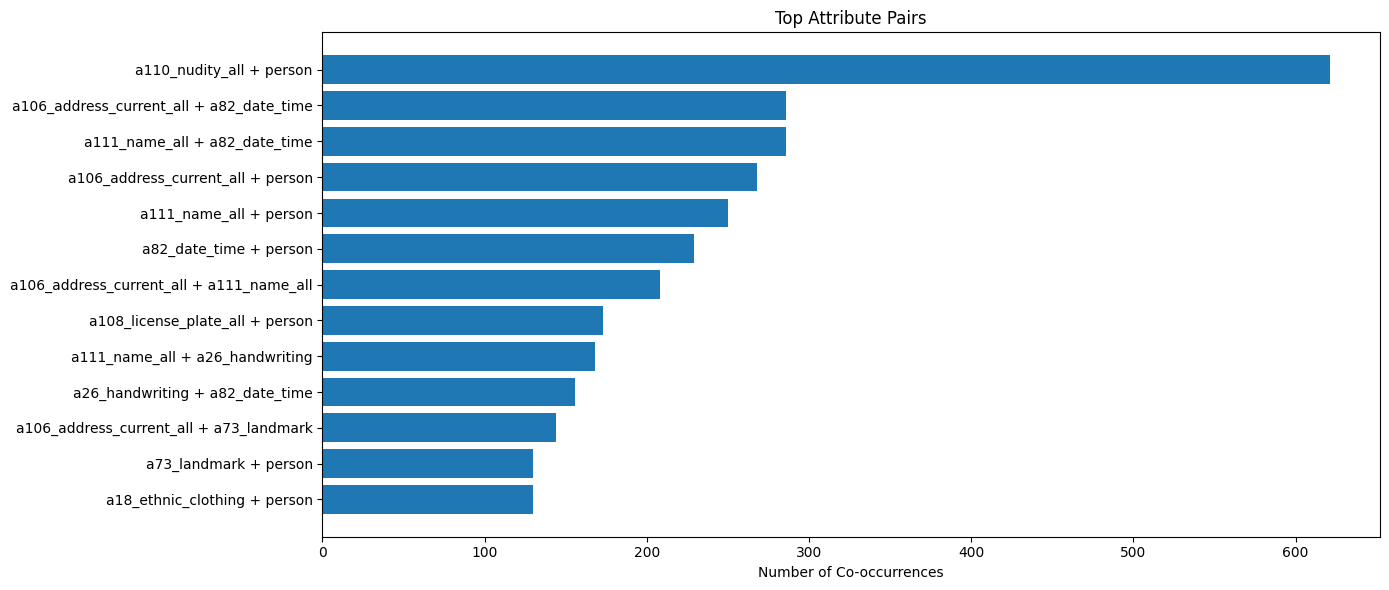

In [ ]:
plot_attr_combinations_bar(top_pairs, title="Top Attribute Pairs", max_bars=30)

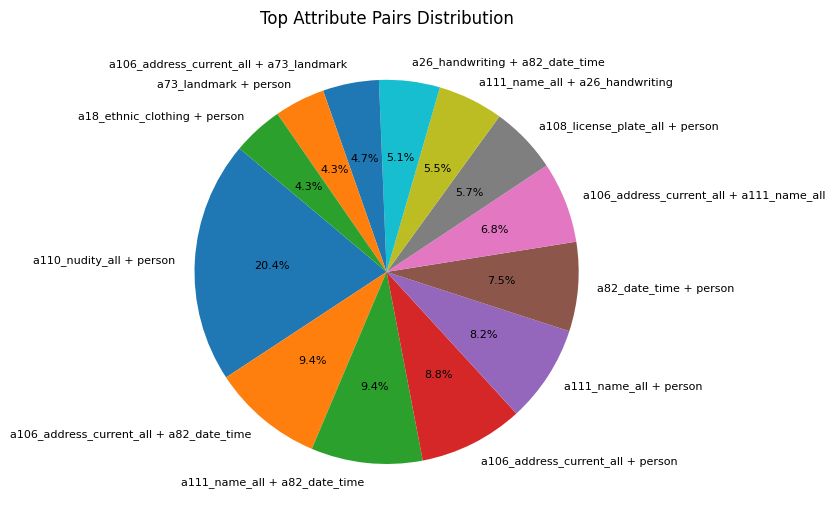

In [ ]:
plot_top_pairs_pie(top_pairs)

In [ ]:
# Get top attribute triples that occur at least 100 times
top_triples = get_top_attr_combinations(filtered_annotations, n=3, min_count=100)
top_triples

[(('a106_address_current_all', 'a111_name_all', 'a82_date_time'), 124)]

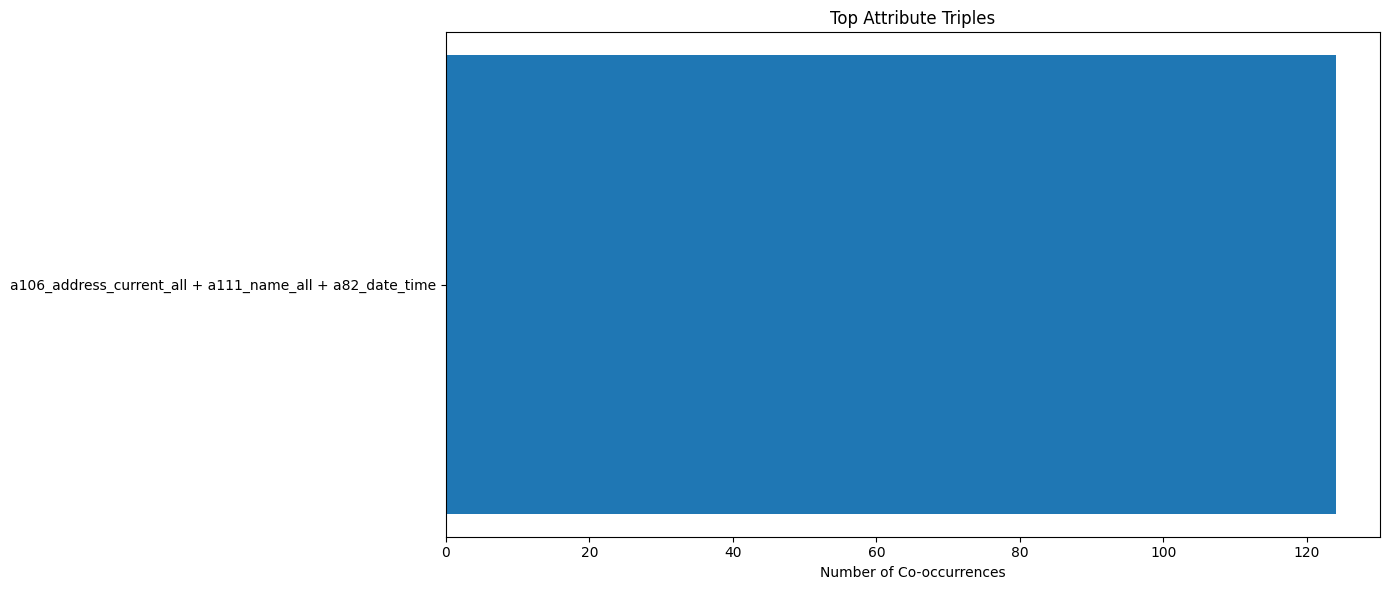

In [ ]:
plot_attr_combinations_bar(top_triples, title="Top Attribute Triples", max_bars=30)

In [ ]:
# Get top attribute quadrables that occur at least 50 times
top_quadruples = get_top_attr_combinations(merged_annotations, n=4, min_count=50)
top_quadruples

[(('a106_address_current_all', 'a111_name_all', 'a82_date_time', 'person'),
  144),
 (('a106_address_current_all', 'a38_ticket', 'a73_landmark', 'a82_date_time'),
  118),
 (('a106_address_current_all',
   'a111_name_all',
   'a26_handwriting',
   'a82_date_time'),
  108),
 (('a106_address_current_all',
   'a111_name_all',
   'a82_date_time',
   'a8_signature'),
  102),
 (('a106_address_current_all',
   'a111_name_all',
   'a73_landmark',
   'a82_date_time'),
  85),
 (('a111_name_all', 'a82_date_time', 'a8_signature', 'person'), 76),
 (('a106_address_current_all', 'a111_name_all', 'a8_signature', 'person'), 73),
 (('a106_address_current_all',
   'a26_handwriting',
   'a82_date_time',
   'a8_signature'),
  68),
 (('a106_address_current_all',
   'a31_passport',
   'a82_date_time',
   'a8_signature'),
  67),
 (('a111_name_all', 'a24_birth_date', 'a82_date_time', 'person'), 65),
 (('a106_address_current_all', 'a82_date_time', 'a8_signature', 'person'), 62),
 (('a106_address_current_all',
  

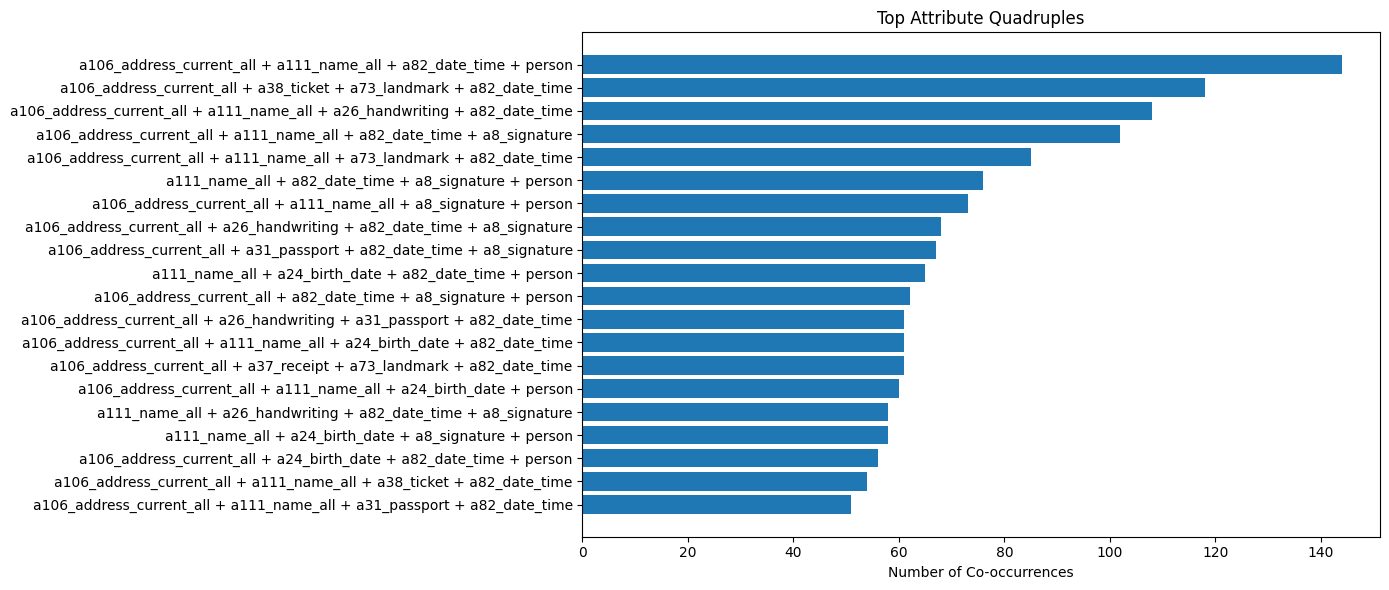

In [ ]:
plot_attr_combinations_bar(top_quadruples, title="Top Attribute Quadruples", max_bars=30)

In [ ]:
# Get top attribute quintuples that occur at least 30 times
top_quintuples = get_top_attr_combinations(merged_annotations, n=5, min_count=30)
top_quintuples

[(('a106_address_current_all',
   'a111_name_all',
   'a82_date_time',
   'a8_signature',
   'person'),
  56),
 (('a106_address_current_all',
   'a111_name_all',
   'a24_birth_date',
   'a82_date_time',
   'person'),
  51),
 (('a106_address_current_all',
   'a26_handwriting',
   'a31_passport',
   'a82_date_time',
   'a8_signature'),
  42),
 (('a106_address_current_all',
   'a111_name_all',
   'a26_handwriting',
   'a82_date_time',
   'a8_signature'),
  38),
 (('a107_address_home_all',
   'a111_name_all',
   'a24_birth_date',
   'a32_drivers_license',
   'person'),
  37),
 (('a106_address_current_all',
   'a111_name_all',
   'a24_birth_date',
   'a8_signature',
   'person'),
  37),
 (('a111_name_all',
   'a24_birth_date',
   'a82_date_time',
   'a8_signature',
   'person'),
  37),
 (('a111_name_all',
   'a24_birth_date',
   'a32_drivers_license',
   'a8_signature',
   'person'),
  35),
 (('a107_address_home_all',
   'a111_name_all',
   'a24_birth_date',
   'a8_signature',
   'person'),

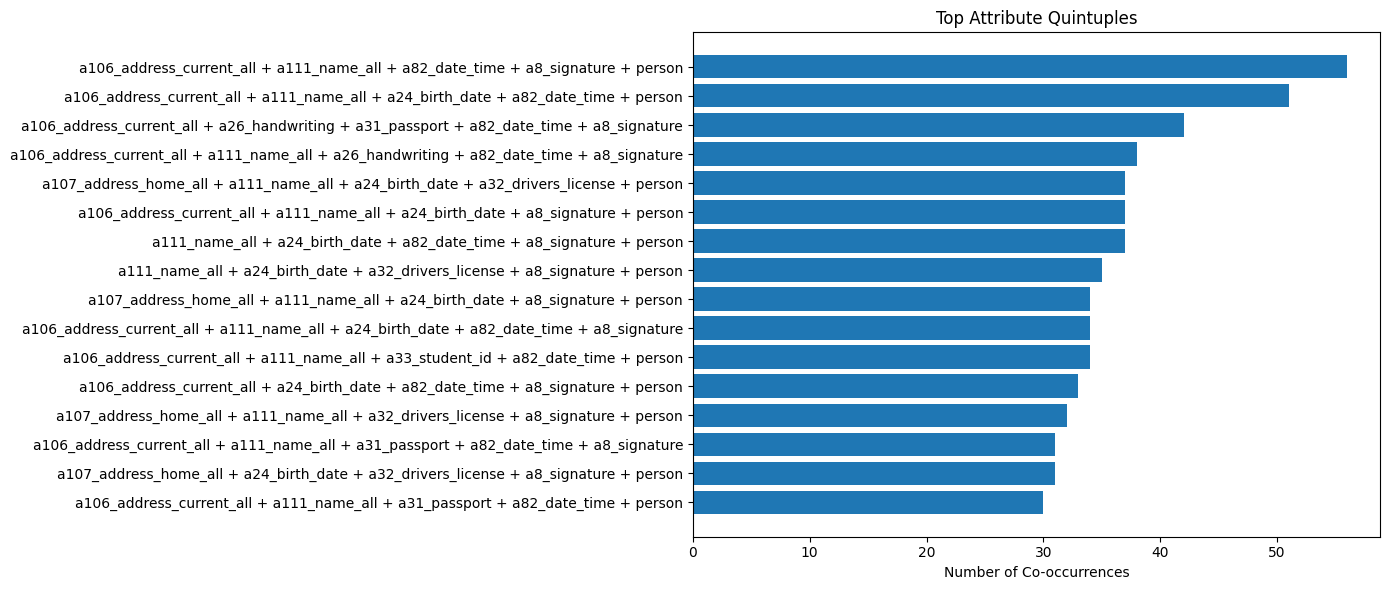

In [ ]:
plot_attr_combinations_bar(top_quintuples, title="Top Attribute Quintuples", max_bars=30)

## Constant-occurences

### Person-Combined

In [ ]:
face_pairs = get_combos_with_label(filtered_annotations, "person", combo_size=2, top_n=10)
face_pairs

[(('a110_nudity_all', 'person'), 621),
 (('a106_address_current_all', 'person'), 268),
 (('a111_name_all', 'person'), 250),
 (('a82_date_time', 'person'), 229),
 (('a108_license_plate_all', 'person'), 173),
 (('a73_landmark', 'person'), 130),
 (('a18_ethnic_clothing', 'person'), 130),
 (('a39_disability_physical', 'person'), 92),
 (('a85_username', 'person'), 58),
 (('a70_education_history', 'person'), 54)]

In [ ]:
inc_face_pairs = get_combos_with_label_inclusive(filtered_annotations, "person", combo_size=2, top_n=10)
inc_face_pairs

[(('person', 'person'), 48335),
 (('a110_nudity_all', 'person'), 3663),
 (('a111_name_all', 'person'), 3062),
 (('a82_date_time', 'person'), 2848),
 (('a106_address_current_all', 'person'), 2426),
 (('a18_ethnic_clothing', 'person'), 1537),
 (('a73_landmark', 'person'), 1245),
 (('a108_license_plate_all', 'person'), 976),
 (('a39_disability_physical', 'person'), 825),
 (('a85_username', 'person'), 802)]

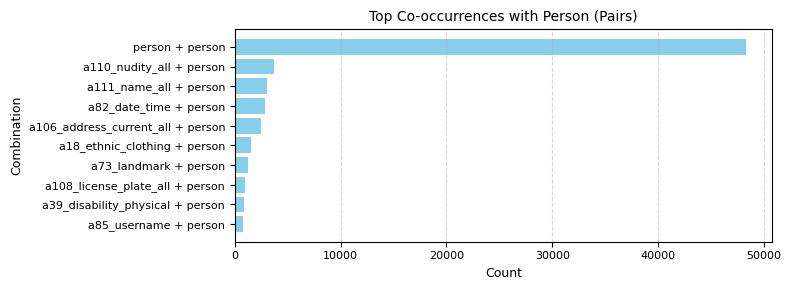

In [ ]:
visualize_label_combos(inc_face_pairs, title="Top Co-occurrences with Person (Pairs)")

In [ ]:
face_triples = get_combos_with_label(merged_annotations, "person", combo_size=3, top_n=10)
face_triples

[(('a106_address_current_all', 'a82_date_time', 'person'), 252),
 (('a111_name_all', 'a82_date_time', 'person'), 219),
 (('a106_address_current_all', 'a111_name_all', 'person'), 201),
 (('a111_name_all', 'a8_signature', 'person'), 125),
 (('a111_name_all', 'a24_birth_date', 'person'), 100),
 (('a82_date_time', 'a8_signature', 'person'), 88),
 (('a106_address_current_all', 'a8_signature', 'person'), 80),
 (('a38_ticket', 'a82_date_time', 'person'), 78),
 (('a73_landmark', 'a82_date_time', 'person'), 73),
 (('a24_birth_date', 'a82_date_time', 'person'), 72)]

In [ ]:
inc_face_triples = get_combos_with_label_inclusive(merged_annotations, "person", combo_size=3, top_n=10)
inc_face_triples

[(('person', 'person', 'person'), 87322),
 (('a82_date_time', 'a82_date_time', 'person'), 32951),
 (('a111_name_all', 'a82_date_time', 'person'), 12802),
 (('a82_date_time', 'person', 'person'), 11123),
 (('a106_address_current_all', 'a82_date_time', 'person'), 10553),
 (('a111_name_all', 'person', 'person'), 10147),
 (('a111_name_all', 'a111_name_all', 'person'), 9678),
 (('a110_nudity_all', 'person', 'person'), 8943),
 (('a106_address_current_all', 'person', 'person'), 7669),
 (('a106_address_current_all', 'a106_address_current_all', 'person'), 6555)]

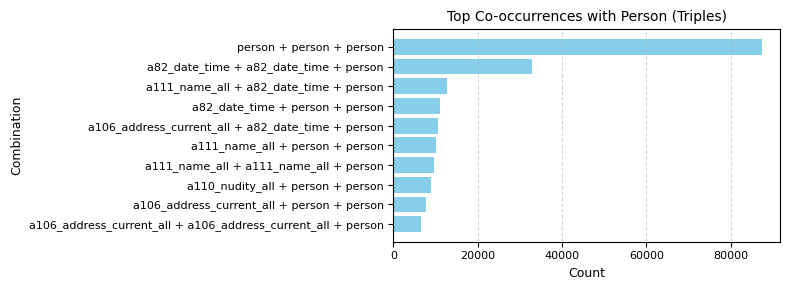

In [ ]:
visualize_label_combos(inc_face_triples, title="Top Co-occurrences with Person (Triples)")

In [ ]:
face_quadruples = get_combos_with_label(merged_annotations, "person", combo_size=4, top_n=10)
face_quadruples

[(('a106_address_current_all', 'a111_name_all', 'a82_date_time', 'person'),
  144),
 (('a111_name_all', 'a82_date_time', 'a8_signature', 'person'), 76),
 (('a106_address_current_all', 'a111_name_all', 'a8_signature', 'person'), 73),
 (('a111_name_all', 'a24_birth_date', 'a82_date_time', 'person'), 65),
 (('a106_address_current_all', 'a82_date_time', 'a8_signature', 'person'), 62),
 (('a106_address_current_all', 'a111_name_all', 'a24_birth_date', 'person'),
  60),
 (('a111_name_all', 'a24_birth_date', 'a8_signature', 'person'), 58),
 (('a106_address_current_all', 'a24_birth_date', 'a82_date_time', 'person'),
  56),
 (('a107_address_home_all', 'a111_name_all', 'a24_birth_date', 'person'), 48),
 (('a106_address_current_all', 'a38_ticket', 'a82_date_time', 'person'), 43)]

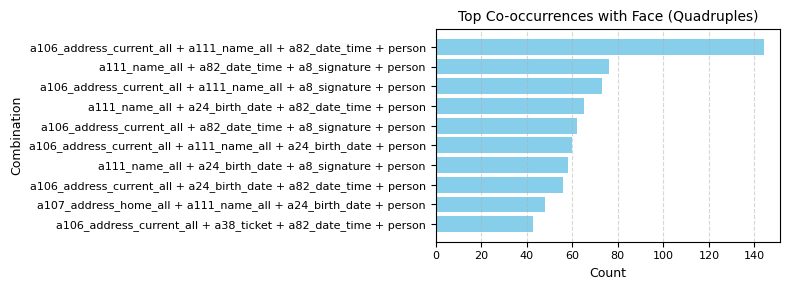

In [ ]:
visualize_label_combos(face_quadruples, title="Top Co-occurrences with Face (Quadruples)")

### a82_date_time


In [ ]:
date_pairs = get_combos_with_label(filtered_annotations, "a82_date_time", combo_size=2, top_n=10)
date_pairs

[(('a106_address_current_all', 'a82_date_time'), 301),
 (('a111_name_all', 'a82_date_time'), 298),
 (('a82_date_time', 'person'), 235),
 (('a26_handwriting', 'a82_date_time'), 160),
 (('a73_landmark', 'a82_date_time'), 92),
 (('a82_date_time', 'a8_signature'), 57),
 (('a82_date_time', 'a85_username'), 39),
 (('a82_date_time', 'a90_email'), 29),
 (('a107_address_home_all', 'a82_date_time'), 25),
 (('a49_phone', 'a82_date_time'), 23)]

In [ ]:
inc_date_pairs = get_combos_with_label_inclusive(filtered_annotations, "a82_date_time", combo_size=2, top_n=10)
inc_date_pairs

[(('a82_date_time', 'a82_date_time'), 54033),
 (('a111_name_all', 'a82_date_time'), 23858),
 (('a106_address_current_all', 'a82_date_time'), 6431),
 (('a82_date_time', 'a85_username'), 6053),
 (('a26_handwriting', 'a82_date_time'), 4570),
 (('a82_date_time', 'person'), 2848),
 (('a73_landmark', 'a82_date_time'), 1098),
 (('a82_date_time', 'a90_email'), 1029),
 (('a107_address_home_all', 'a82_date_time'), 607),
 (('a24_birth_date', 'a82_date_time'), 395)]

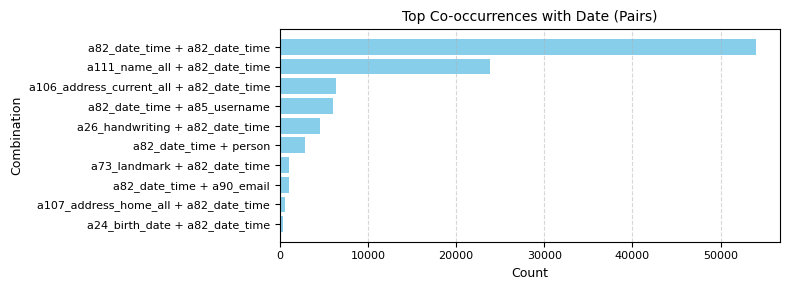

In [ ]:
visualize_label_combos(inc_date_pairs, title="Top Co-occurrences with Date (Pairs)")

In [ ]:
date_triples = get_combos_with_label(filtered_annotations, "a82_date_time", combo_size=3, top_n=10)
date_triples

[(('a106_address_current_all', 'a111_name_all', 'a82_date_time'), 134),
 (('a106_address_current_all', 'a82_date_time', 'person'), 94),
 (('a111_name_all', 'a26_handwriting', 'a82_date_time'), 86),
 (('a111_name_all', 'a82_date_time', 'person'), 81),
 (('a106_address_current_all', 'a26_handwriting', 'a82_date_time'), 66),
 (('a106_address_current_all', 'a73_landmark', 'a82_date_time'), 61),
 (('a111_name_all', 'a82_date_time', 'a8_signature'), 41),
 (('a111_name_all', 'a73_landmark', 'a82_date_time'), 34),
 (('a106_address_current_all', 'a82_date_time', 'a8_signature'), 29),
 (('a82_date_time', 'a85_username', 'person'), 27)]

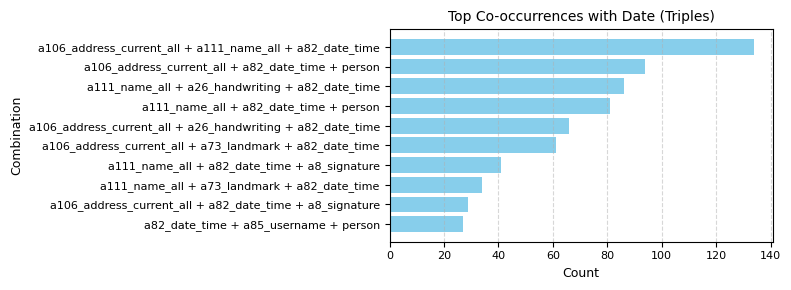

In [ ]:
visualize_label_combos(date_triples, title="Top Co-occurrences with Date (Triples)")

In [ ]:
date_quadruples = get_combos_with_label(filtered_annotations, "a82_date_time", combo_size=4, top_n=10)
date_quadruples

[(('a106_address_current_all',
   'a111_name_all',
   'a26_handwriting',
   'a82_date_time'),
  38),
 (('a106_address_current_all', 'a111_name_all', 'a82_date_time', 'person'),
  35),
 (('a106_address_current_all',
   'a111_name_all',
   'a73_landmark',
   'a82_date_time'),
  21),
 (('a106_address_current_all',
   'a111_name_all',
   'a82_date_time',
   'a8_signature'),
  21),
 (('a106_address_current_all',
   'a107_address_home_all',
   'a111_name_all',
   'a82_date_time'),
  18),
 (('a111_name_all', 'a70_education_history', 'a82_date_time', 'a8_signature'),
  15),
 (('a111_name_all', 'a26_handwriting', 'a82_date_time', 'a8_signature'), 15),
 (('a106_address_current_all',
   'a111_name_all',
   'a24_birth_date',
   'a82_date_time'),
  14),
 (('a106_address_current_all',
   'a26_handwriting',
   'a82_date_time',
   'a8_signature'),
  12),
 (('a111_name_all', 'a24_birth_date', 'a82_date_time', 'person'), 12)]

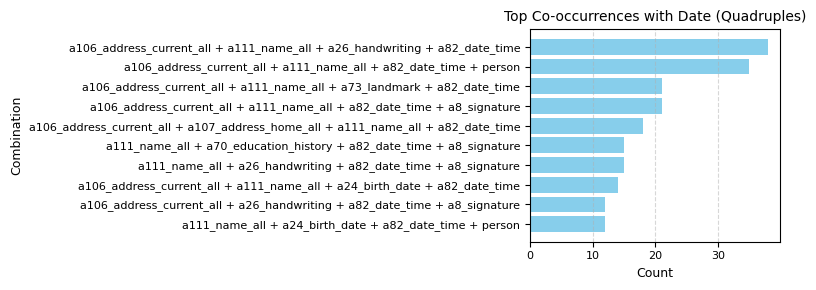

In [ ]:
visualize_label_combos(date_quadruples, title="Top Co-occurrences with Date (Quadruples)")

### a111_name_all


In [ ]:
name_pairs = get_combos_with_label(filtered_annotations, "a111_name_all", combo_size=2, top_n=10)
name_pairs

[(('a111_name_all', 'a82_date_time'), 298),
 (('a111_name_all', 'person'), 255),
 (('a106_address_current_all', 'a111_name_all'), 223),
 (('a111_name_all', 'a26_handwriting'), 170),
 (('a111_name_all', 'a8_signature'), 68),
 (('a111_name_all', 'a73_landmark'), 55),
 (('a111_name_all', 'a90_email'), 54),
 (('a111_name_all', 'a49_phone'), 40),
 (('a111_name_all', 'a70_education_history'), 38),
 (('a107_address_home_all', 'a111_name_all'), 37)]

In [ ]:
inc_name_pairs = get_combos_with_label_inclusive(filtered_annotations, "a111_name_all", combo_size=2, top_n=10)
inc_name_pairs

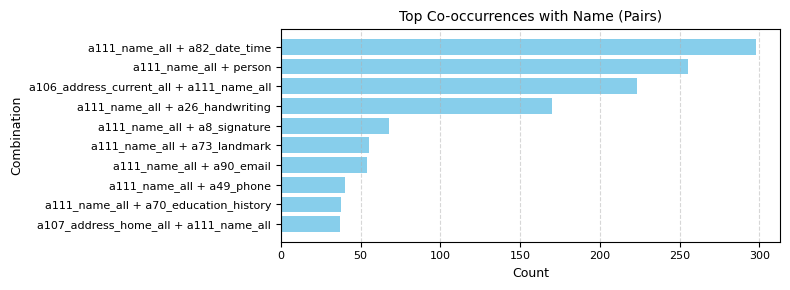

In [ ]:
visualize_label_combos(name_pairs, title="Top Co-occurrences with Name (Pairs)")

In [ ]:
name_triples = get_combos_with_label(filtered_annotations, "a111_name_all", combo_size=3, top_n=10)
name_triples

[(('a106_address_current_all', 'a111_name_all', 'a82_date_time'), 134),
 (('a111_name_all', 'a26_handwriting', 'a82_date_time'), 86),
 (('a111_name_all', 'a82_date_time', 'person'), 81),
 (('a106_address_current_all', 'a111_name_all', 'person'), 68),
 (('a106_address_current_all', 'a111_name_all', 'a26_handwriting'), 49),
 (('a111_name_all', 'a82_date_time', 'a8_signature'), 41),
 (('a111_name_all', 'a73_landmark', 'a82_date_time'), 34),
 (('a106_address_current_all', 'a111_name_all', 'a73_landmark'), 29),
 (('a106_address_current_all', 'a111_name_all', 'a8_signature'), 28),
 (('a111_name_all', 'a70_education_history', 'a8_signature'), 25)]

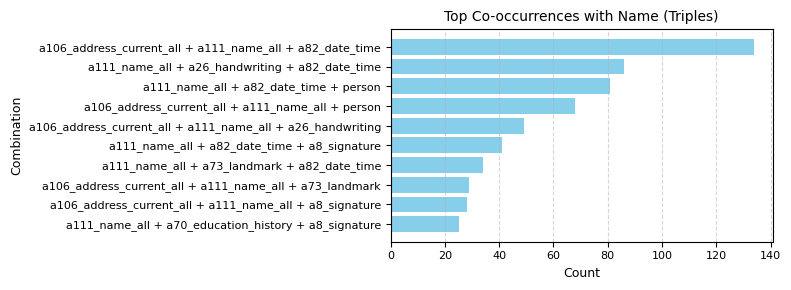

In [ ]:
visualize_label_combos(name_triples, title="Top Co-occurrences with Name (Triples)")

In [ ]:
name_quadruples = get_combos_with_label(filtered_annotations, "a111_name_all", combo_size=4, top_n=10)
name_quadruples

[(('a106_address_current_all',
   'a111_name_all',
   'a26_handwriting',
   'a82_date_time'),
  38),
 (('a106_address_current_all', 'a111_name_all', 'a82_date_time', 'person'),
  35),
 (('a106_address_current_all',
   'a111_name_all',
   'a73_landmark',
   'a82_date_time'),
  21),
 (('a106_address_current_all',
   'a111_name_all',
   'a82_date_time',
   'a8_signature'),
  21),
 (('a106_address_current_all',
   'a107_address_home_all',
   'a111_name_all',
   'a82_date_time'),
  18),
 (('a111_name_all', 'a70_education_history', 'a82_date_time', 'a8_signature'),
  15),
 (('a111_name_all', 'a26_handwriting', 'a82_date_time', 'a8_signature'), 15),
 (('a106_address_current_all',
   'a111_name_all',
   'a24_birth_date',
   'a82_date_time'),
  14),
 (('a111_name_all', 'a70_education_history', 'a8_signature', 'person'), 12),
 (('a111_name_all', 'a24_birth_date', 'a82_date_time', 'person'), 12)]

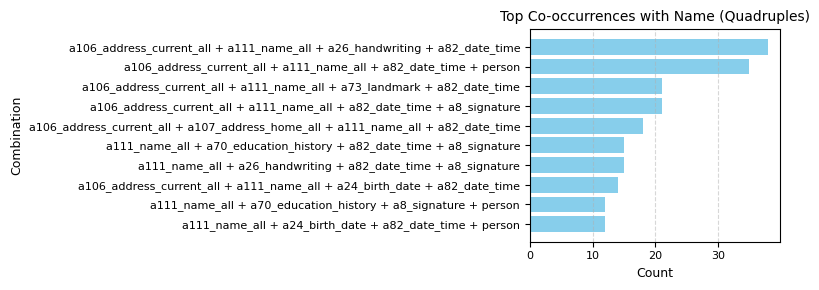

In [ ]:
visualize_label_combos(name_quadruples, title="Top Co-occurrences with Name (Quadruples)")

### a106_address_current_all

In [ ]:
address_pairs = get_combos_with_label(filtered_annotations, "a106_address_current_all", combo_size=2, top_n=10)
address_pairs

[(('a106_address_current_all', 'a82_date_time'), 301),
 (('a106_address_current_all', 'person'), 278),
 (('a106_address_current_all', 'a111_name_all'), 223),
 (('a106_address_current_all', 'a73_landmark'), 159),
 (('a106_address_current_all', 'a26_handwriting'), 94),
 (('a106_address_current_all', 'a108_license_plate_all'), 83),
 (('a106_address_current_all', 'a8_signature'), 41),
 (('a106_address_current_all', 'a49_phone'), 39),
 (('a106_address_current_all', 'a107_address_home_all'), 30),
 (('a106_address_current_all', 'a70_education_history'), 20)]

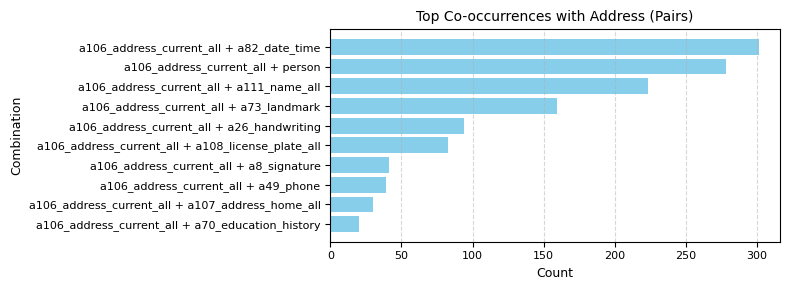

In [ ]:
visualize_label_combos(address_pairs, title="Top Co-occurrences with Address (Pairs)")

In [ ]:
address_triples = get_combos_with_label(filtered_annotations, "a106_address_current_all", combo_size=3, top_n=10)
address_triples

[(('a106_address_current_all', 'a111_name_all', 'a82_date_time'), 134),
 (('a106_address_current_all', 'a82_date_time', 'person'), 94),
 (('a106_address_current_all', 'a111_name_all', 'person'), 68),
 (('a106_address_current_all', 'a26_handwriting', 'a82_date_time'), 66),
 (('a106_address_current_all', 'a73_landmark', 'a82_date_time'), 61),
 (('a106_address_current_all', 'a111_name_all', 'a26_handwriting'), 49),
 (('a106_address_current_all', 'a73_landmark', 'person'), 30),
 (('a106_address_current_all', 'a111_name_all', 'a73_landmark'), 29),
 (('a106_address_current_all', 'a82_date_time', 'a8_signature'), 29),
 (('a106_address_current_all', 'a111_name_all', 'a8_signature'), 28)]

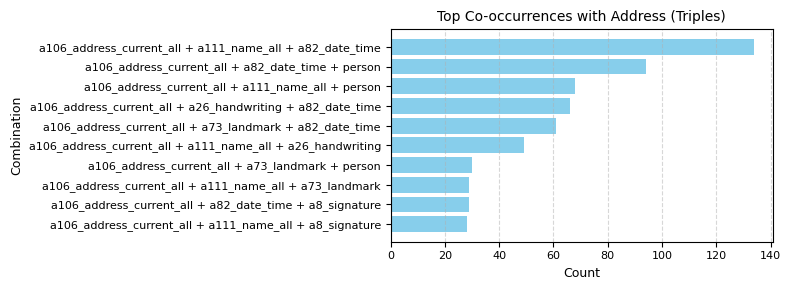

In [ ]:
visualize_label_combos(address_triples, title="Top Co-occurrences with Address (Triples)")

In [ ]:
address_quadruples = get_combos_with_label(filtered_annotations, "a106_address_current_all", combo_size=4, top_n=10)
address_quadruples

[(('a106_address_current_all',
   'a111_name_all',
   'a26_handwriting',
   'a82_date_time'),
  38),
 (('a106_address_current_all', 'a111_name_all', 'a82_date_time', 'person'),
  35),
 (('a106_address_current_all',
   'a111_name_all',
   'a73_landmark',
   'a82_date_time'),
  21),
 (('a106_address_current_all',
   'a111_name_all',
   'a82_date_time',
   'a8_signature'),
  21),
 (('a106_address_current_all',
   'a107_address_home_all',
   'a111_name_all',
   'a82_date_time'),
  18),
 (('a106_address_current_all',
   'a111_name_all',
   'a24_birth_date',
   'a82_date_time'),
  14),
 (('a106_address_current_all',
   'a26_handwriting',
   'a82_date_time',
   'a8_signature'),
  12),
 (('a106_address_current_all',
   'a107_address_home_all',
   'a111_name_all',
   'person'),
  12),
 (('a106_address_current_all',
   'a111_name_all',
   'a70_education_history',
   'a8_signature'),
  11),
 (('a106_address_current_all',
   'a73_landmark',
   'a82_date_time',
   'a8_signature'),
  11)]

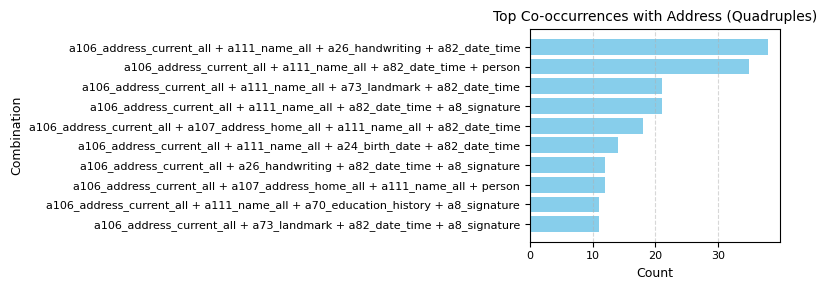

In [ ]:
visualize_label_combos(address_quadruples, title="Top Co-occurrences with Address (Quadruples)")

### a26_handwriting

In [ ]:
handwriting_pairs = get_combos_with_label(filtered_annotations, "a26_handwriting", combo_size=2, top_n=10)
handwriting_pairs

[(('a111_name_all', 'a26_handwriting'), 170),
 (('a26_handwriting', 'a82_date_time'), 160),
 (('a106_address_current_all', 'a26_handwriting'), 94),
 (('a26_handwriting', 'a8_signature'), 46),
 (('a26_handwriting', 'person'), 20),
 (('a26_handwriting', 'a73_landmark'), 16),
 (('a107_address_home_all', 'a26_handwriting'), 11),
 (('a26_handwriting', 'a70_education_history'), 10),
 (('a24_birth_date', 'a26_handwriting'), 9),
 (('a26_handwriting', 'a49_phone'), 7)]

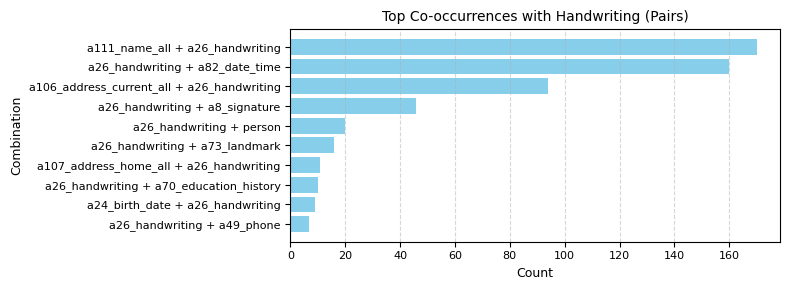

In [ ]:
visualize_label_combos(handwriting_pairs, title="Top Co-occurrences with Handwriting (Pairs)")

In [ ]:
handwriting_triples = get_combos_with_label(filtered_annotations, "a26_handwriting", combo_size=3, top_n=10)
handwriting_triples

[(('a111_name_all', 'a26_handwriting', 'a82_date_time'), 86),
 (('a106_address_current_all', 'a26_handwriting', 'a82_date_time'), 66),
 (('a106_address_current_all', 'a111_name_all', 'a26_handwriting'), 49),
 (('a26_handwriting', 'a82_date_time', 'a8_signature'), 26),
 (('a111_name_all', 'a26_handwriting', 'a8_signature'), 24),
 (('a106_address_current_all', 'a26_handwriting', 'a8_signature'), 17),
 (('a106_address_current_all', 'a26_handwriting', 'a73_landmark'), 12),
 (('a26_handwriting', 'a73_landmark', 'a82_date_time'), 11),
 (('a111_name_all', 'a26_handwriting', 'a70_education_history'), 10),
 (('a111_name_all', 'a26_handwriting', 'person'), 10)]

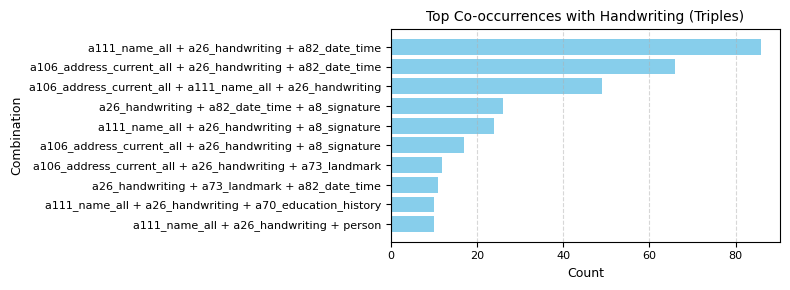

In [ ]:
visualize_label_combos(handwriting_triples, title="Top Co-occurrences with Handwriting (Triples)")

In [ ]:
handwriting_quadruples = get_combos_with_label(filtered_annotations, "a26_handwriting", combo_size=4, top_n=10)
handwriting_quadruples

[(('a106_address_current_all',
   'a111_name_all',
   'a26_handwriting',
   'a82_date_time'),
  38),
 (('a111_name_all', 'a26_handwriting', 'a82_date_time', 'a8_signature'), 15),
 (('a106_address_current_all',
   'a26_handwriting',
   'a82_date_time',
   'a8_signature'),
  12),
 (('a106_address_current_all',
   'a26_handwriting',
   'a73_landmark',
   'a82_date_time'),
  9),
 (('a106_address_current_all',
   'a111_name_all',
   'a26_handwriting',
   'a8_signature'),
  9),
 (('a111_name_all',
   'a26_handwriting',
   'a70_education_history',
   'a8_signature'),
  6),
 (('a111_name_all', 'a24_birth_date', 'a26_handwriting', 'a82_date_time'), 6),
 (('a111_name_all', 'a26_handwriting', 'a73_landmark', 'a82_date_time'), 5),
 (('a106_address_current_all',
   'a111_name_all',
   'a24_birth_date',
   'a26_handwriting'),
  5),
 (('a106_address_current_all',
   'a107_address_home_all',
   'a26_handwriting',
   'a82_date_time'),
  5)]

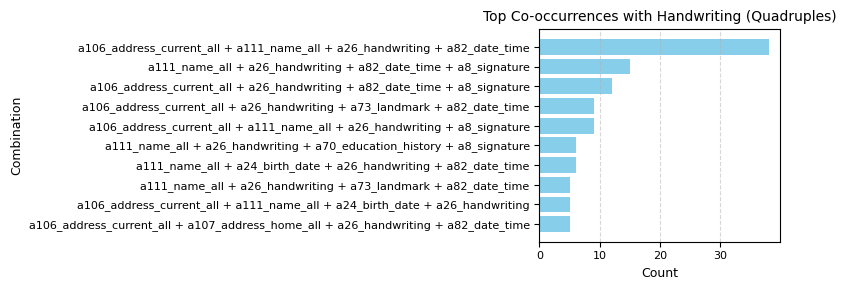

In [ ]:
visualize_label_combos(handwriting_quadruples, title="Top Co-occurrences with Handwriting (Quadruples)")

### a73_landmark

In [ ]:
landmark_pairs = get_combos_with_label(filtered_annotations, "a73_landmark", combo_size=2, top_n=10)
landmark_pairs

[(('a106_address_current_all', 'a73_landmark'), 159),
 (('a73_landmark', 'person'), 136),
 (('a73_landmark', 'a82_date_time'), 92),
 (('a111_name_all', 'a73_landmark'), 55),
 (('a108_license_plate_all', 'a73_landmark'), 26),
 (('a49_phone', 'a73_landmark'), 25),
 (('a73_landmark', 'a8_signature'), 21),
 (('a70_education_history', 'a73_landmark'), 18),
 (('a26_handwriting', 'a73_landmark'), 16),
 (('a73_landmark', 'a90_email'), 7)]

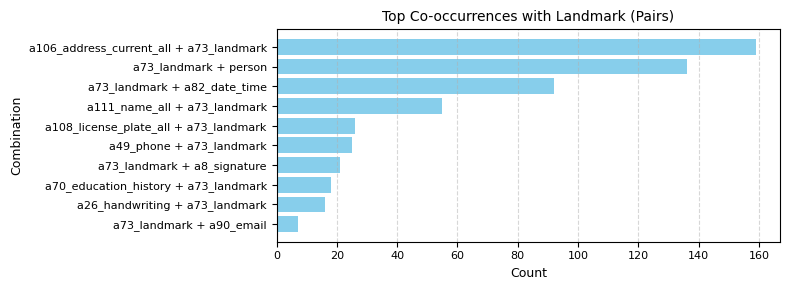

In [ ]:
visualize_label_combos(landmark_pairs, title="Top Co-occurrences with Landmark (Pairs)")

In [ ]:
landmark_triples = get_combos_with_label(filtered_annotations, "a73_landmark", combo_size=3, top_n=10)
landmark_triples

[(('a106_address_current_all', 'a73_landmark', 'a82_date_time'), 61),
 (('a111_name_all', 'a73_landmark', 'a82_date_time'), 34),
 (('a106_address_current_all', 'a73_landmark', 'person'), 30),
 (('a106_address_current_all', 'a111_name_all', 'a73_landmark'), 29),
 (('a73_landmark', 'a82_date_time', 'a8_signature'), 18),
 (('a106_address_current_all', 'a49_phone', 'a73_landmark'), 15),
 (('a111_name_all', 'a73_landmark', 'a8_signature'), 14),
 (('a73_landmark', 'a82_date_time', 'person'), 13),
 (('a106_address_current_all', 'a26_handwriting', 'a73_landmark'), 12),
 (('a111_name_all', 'a73_landmark', 'person'), 12)]

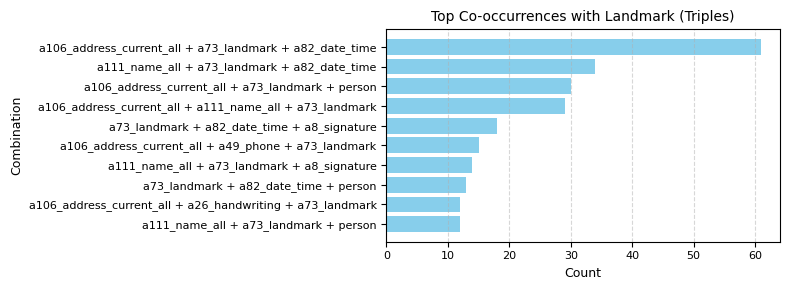

In [ ]:
visualize_label_combos(landmark_triples, title="Top Co-occurrences with Landmark (Triples)")

In [ ]:
landmark_quadruples = get_combos_with_label(filtered_annotations, "a73_landmark", combo_size=4, top_n=10)
landmark_quadruples

[(('a106_address_current_all',
   'a111_name_all',
   'a73_landmark',
   'a82_date_time'),
  21),
 (('a111_name_all', 'a73_landmark', 'a82_date_time', 'a8_signature'), 12),
 (('a106_address_current_all',
   'a73_landmark',
   'a82_date_time',
   'a8_signature'),
  11),
 (('a106_address_current_all',
   'a26_handwriting',
   'a73_landmark',
   'a82_date_time'),
  9),
 (('a106_address_current_all',
   'a111_name_all',
   'a73_landmark',
   'a8_signature'),
  8),
 (('a111_name_all', 'a70_education_history', 'a73_landmark', 'a82_date_time'),
  7),
 (('a111_name_all', 'a70_education_history', 'a73_landmark', 'a8_signature'),
  7),
 (('a70_education_history', 'a73_landmark', 'a82_date_time', 'a8_signature'),
  7),
 (('a111_name_all', 'a73_landmark', 'a82_date_time', 'person'), 6),
 (('a106_address_current_all', 'a73_landmark', 'a82_date_time', 'person'), 6)]

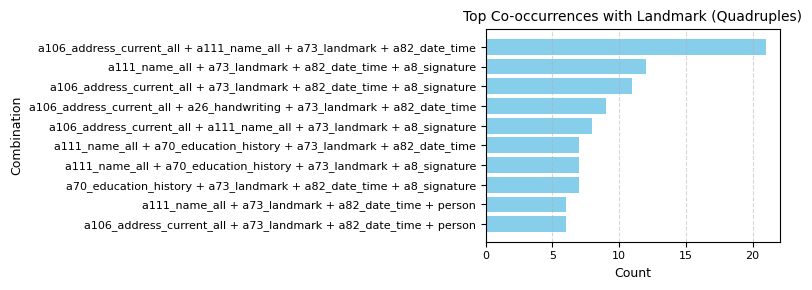

In [ ]:
visualize_label_combos(landmark_quadruples, title="Top Co-occurrences with Landmark (Quadruples)")

In [ ]:
def print_images_with_specific_attrs(annotations_data):
    required_attrs = {"person", "a106_address_current_all", "a82_date_time"}

    for image_id, image in annotations_data.items():
        attr_ids = {attr["attr_id"] for attr in image.get("attributes", [])}
        if required_attrs.issubset(attr_ids):
            print(image_id)
print_images_with_specific_attrs(filtered_annotations)

2017_67690379
2017_38009928
2017_51280318
2017_59699061
2017_53067255
2017_86617785
2017_71606010
2017_55505141
2017_40202843
2017_93127116
2017_62551360
2017_35891722
2017_76969020
2017_34081052
2017_30197785
2017_47200329
2017_12529003
2017_74131416
2017_48851552
2017_41037957
2017_64901734
2017_50191230
2017_92059234
2017_35448661
2017_99870808
2017_42002436
2017_63417959
2017_19711337
2017_45083590
2017_55649980
2017_53403142
2017_60676585
2017_44066173
2017_21766272
2017_84654506
2017_22999127
2017_90933134
2017_84153080
2017_10624128
2017_52620275
2017_41218158
2017_48910217
2017_45193819
2017_34310136
2017_47368792
2017_63475673
2017_36968377
2017_41762639
2017_71188469
2017_51566681
2017_96110609
2017_23775170
2017_89338811
2017_47357338
2017_52020794
2017_79057763
2017_51914571
2017_67295155
2017_49384854
2017_99786422
2017_70974240
2017_51564885
2017_14396749
2017_95768331
2017_28873108
2017_85686028
2017_24947072
2017_10142451
2017_45394249
2017_64072888
2017_46454553
2017_5

# Segmentation Example

In [ ]:
import json

# Load the annotations from the specific file
with open("/content/drive/MyDrive/nokia/annotations2.json", "r") as f:
    annotations_data = json.load(f)

# Get and print all image IDs
image_ids = list(annotations_data["annotations"].keys())

In [ ]:
target_attrs = {"a109_person_body", "a82_date_time"}
matching_ids = []

for img_id, data in annotations_data["annotations"].items():
    attr_ids = {attr["attr_id"] for attr in data.get("attributes", [])}
    if target_attrs.issubset(attr_ids):
        matching_ids.append(img_id)

# Print matching image IDs
#print("Images with person, date:")
#for img_id in matching_ids:
   # print(img_id)


In [ ]:
image_id = "2017_88375462"
image_data = annotations_data["annotations"].get(image_id)

if image_data:
    from pprint import pprint
    pprint(image_data)
else:
    print(f"No data found for image ID: {image_id}")


{'attributes': [{'area': 888303,
                 'attr_id': 'a109_person_body',
                 'bbox': [3159.0, 594.0, 1005.0, 1357.0],
                 'instance_id': 0,
                 'iscrowd': False,
                 'polygons': [[3639,
                               594,
                               3787,
                               634,
                               3911,
                               762,
                               3975,
                               896,
                               4005,
                               1114,
                               4040,
                               1154,
                               4000,
                               1302,
                               3961,
                               1376,
                               3901,
                               1520,
                               4000,
                               1753,
                               4060,
                  

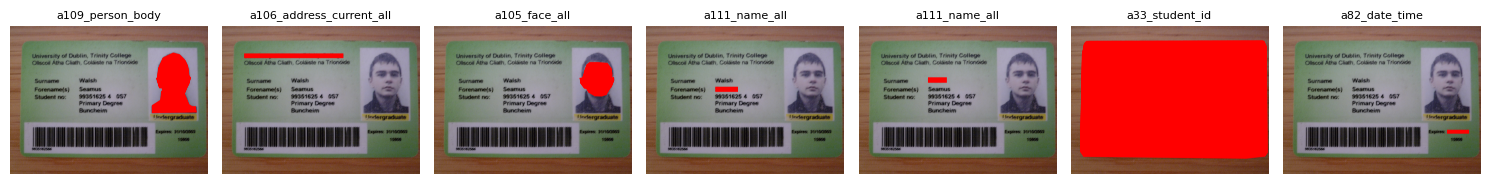

In [ ]:
from pycocotools import mask as mask_utils
import matplotlib.pyplot as plt
import numpy as np
import cv2

image_id = "2017_88375462"
image_path = f"/content/{image_id}.jpg"

# Load original image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

ann = annotations_data["annotations"][image_id]
height, width = ann["image_height"], ann["image_width"]

plt.figure(figsize=(15, 5))

for idx, attr in enumerate(ann["attributes"]):
    seg = attr["segmentation"]

    if isinstance(seg["counts"], str):  # compressed RLE
        rle = {
            "counts": seg["counts"],
            "size": seg["size"]
        }
        mask = mask_utils.decode(rle)
    else:
        continue  # skip if not a valid compressed RLE

    # Show the mask over the image
    overlay = img.copy()
    overlay[mask[:, :] > 0] = [255, 0, 0]

    plt.subplot(1, len(ann["attributes"]), idx + 1)
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(attr["attr_id"], fontsize=8)

plt.tight_layout()
plt.show()


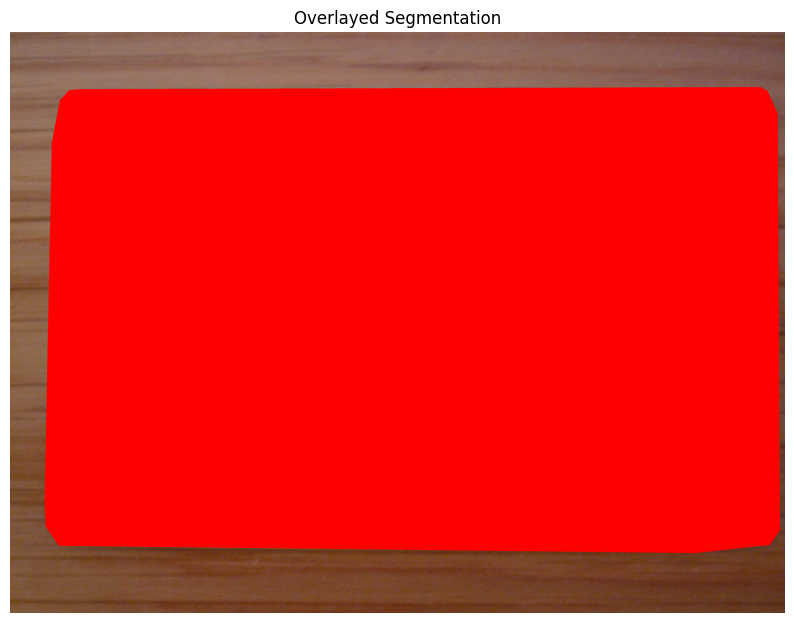

In [ ]:
mask_overlay = np.zeros((height, width), dtype=np.uint8)

for attr in ann["attributes"]:
    seg = attr["segmentation"]
    # Decode directly (this is compressed RLE)
    rle = {
        "counts": seg["counts"],
        "size": seg["size"]
    }
    binary_mask = mask_utils.decode(rle)
    mask_overlay = np.maximum(mask_overlay, binary_mask * 255)

# Resize overlay to match image (if needed)
mask_overlay = cv2.resize(mask_overlay, (img.shape[1], img.shape[0]))

# Overlay the mask
overlay_img = img.copy()
overlay_img[mask_overlay > 0] = [255, 0, 0]  # red overlay

# Show result
plt.figure(figsize=(10, 10))
plt.imshow(overlay_img)
plt.axis("off")
plt.title("Overlayed Segmentation")
plt.show()

In [ ]:
def print_segmentations(image_id, annotations_data):
    image_data = annotations_data["annotations"].get(image_id)

    if not image_data:
        print(f"Image ID {image_id} not found.")
        return

    for attr in image_data.get("attributes", []):
        attr_id = attr.get("attr_id", "Unknown")
        segmentation = attr.get("segmentation")
        print(f"Attribute: {attr_id}")
        print("Segmentation:")
        print(segmentation)
        print("-" * 40)

# Example usage
print_segmentations("2017_12276591", annotations_data)


Attribute: a109_person_body
Segmentation:
{'counts': 'oU1b1Vb010000O10000O10000O10000O10000O100O10000O10000O100O10000O10000O10000O1000000O1000000O10000O10000O100O100O10000O100O10000O100O10000O100O100O10000O100O100O10000O100O100O100O10000O100O1O100O1O1\\I\\MSLd2l3bMnK_2P4hMjKY2U4lMgKT2X4nMfKS2Q3`MnG`0o4P2f2TNSHOT5n1`2dNSHAZ5l1_2nNoGXOa5j1\\2;aMFZ2b0cM^OY2j0cMVOY2Q1cMPOY2X1cMhNZ2_1aMbN]2d1_M\\N`2h1]MXNa2n1ZMSNd2R2YMnMf2U2WMlMg2X2WMhMg2[2XMeMg2^2VMcMh2a2VM_Mh2e2VM[Mi2g2UMZMi2h2VMYMh2i2UMZMj2h2SMZMk2h2SMZMk2h2SMZMl2g2QM\\Mm2f2QM\\Mo2e2oL\\MP3e2oL\\MP3f2nL[MQ3i2lLWMS3m2iLTMV3P3gLPMX3T3dLmL[3V3bLkL]3Y3`LgL_3\\3^LeLa3_3\\LaLc3b3ZL_Le3e3XL[Lg3h3WLXLh3k3ULVLk3m3RLSLm3Q4PLoKo3V4lKkKS4Z4iKfKV4_4fKaKY4e4aK\\K^4i4^KWKa4Q:O1O1O1O1O1O100O1O100O1O100O1O100O1O100O1O100O1O100O100O1O100O1O100O10000O10000O10000O10000O10000O10000O10000O10000O10000O1000000O100000000O100000000O100000000O100000000O100000000O100000000001O00000000001O0000000000001O00000000001O00000000001O00000000001O0000001O001O00001O001O001O00

In [ ]:
image_path = "2017_88375462.jpg"

# Your segmentation data
segmentation = {
    'counts': 'oU1b1Vb010000O10000O10000O10000O10000O100O10000O10000O100O10000O10000O10000O1000000O1000000O10000O10000O100O100O10000O100O10000O100O10000O100O100O10000O100O100O10000O100O100O100O10000O100O1O100O1O1\\I\\MSLd2l3bMnK_2P4hMjKY2U4lMgKT2X4nMfKS2Q3`MnG`0o4P2f2TNSHOT5n1`2dNSHAZ5l1_2nNoGXOa5j1\\2;aMFZ2b0cM^OY2j0cMVOY2Q1cMPOY2X1cMhNZ2_1aMbN]2d1_M\\N`2h1]MXNa2n1ZMSNd2R2YMnMf2U2WMlMg2X2WMhMg2[2XMeMg2^2VMcMh2a2VM_Mh2e2VM[Mi2g2UMZMi2h2VMYMh2i2UMZMj2h2SMZMk2h2SMZMk2h2SMZMl2g2QM\\Mm2f2QM\\Mo2e2oL\\MP3e2oL\\MP3f2nL[MQ3i2lLWMS3m2iLTMV3P3gLPMX3T3dLmL[3V3bLkL]3Y3`LgL_3\\3^LeLa3_3\\LaLc3b3ZL_Le3e3XL[Lg3h3WLXLh3k3ULVLk3m3RLSLm3Q4PLoKo3V4lKkKS4Z4iKfKV4_4fKaKY4e4aK\\K^4i4^KWKa4Q:O1O1O1O1O1O100O1O100O1O100O1O100O1O100O1O100O1O100O100O1O100O1O100O10000O10000O10000O10000O10000O10000O10000O10000O10000O1000000O100000000O100000000O100000000O100000000O100000000O100000000001O00000000001O0000000000001O00000000001O00000000001O00000000001O0000001O001O00001O001O001O001O001O00001O001O001O001O00001O001O001O001O1O1O001O1O001O1O1O001O1lKeJhI\\5l5PKSJP5e5YKZJh4`5^K_Jc4[5bKeJ_4V5fKiJZ4T5jKkJW4P5nKoJS4m4PLSKQ4i4SLVKm3f4XLYKi3c4[L\\Kf3`4]L`Kd3\\4`LcK`3Z4dLeK^3V4fLiK[3T4hLkKY3S4iLlKX3Q4kLnKV3n3nLQLS3j3RMULo2g3TMYLm2b3YM\\Lh2_3_M^Lb2^3dM_L^2]3fMaL[2]3gMbLZ2\\3hMcLY2[3hMeLY2Y3iMfLX2W3jMiLW2T3lMkLU2R3nMmLS2P3oMPMS2m2oMRMS2j2PNUMQ2h2QNXMQ2c2SN\\Mo1`2TN_Mn1]2TNcMn1Z2TNeMn1X2SNhMn1U2UNjMm1S2UNlMm1Q2TNoMn1n1TNQNo1j1TNUNP2e1RN[NS2]1QNbNS2XObHM]5k0T4SOnKm0R4kNWLT1i3dN_L\\1b3_NbLa1^3[NgLd1Y3XNkLh1W3PNoLP2T3eMUMZ2U:0001O001O00001O00001O00001O00001O001O00001O00001O00001O00001O001O00001O00001O00001O001O00001O001O00001O001O00001O001O001O00001O001O00001O001O00001O001O00001O001O001O00001O001O001O00001O001O001O00001O001O001O001O00001O001O001O001O00001O001O001O1O001O1O001O1O001O001O1O001O1O001O1O001O1O001O1O001O1O001O1OkQ]9',
    'size': [633, 1024]
}

In [ ]:
import cv2
import numpy as np
from pycocotools import mask as mask_utils
import matplotlib.pyplot as plt

def color_segmented_area(image_path, segmentation):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = segmentation['size']

    rle = {
        "counts": segmentation["counts"].encode('utf-8'),
        "size": segmentation["size"]
    }
    mask = mask_utils.decode(rle).astype(bool)

    # Color the area
    result = img.copy()
    result[mask] = [0, 0, 0]

    # Draw contour
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(result, contours, -1, (255, 0, 0), thickness=3)

    plt.figure(figsize=(10, 10))
    plt.imshow(result)
    plt.axis('off')
    plt.title("Colored Segment with Outline")
    plt.show()

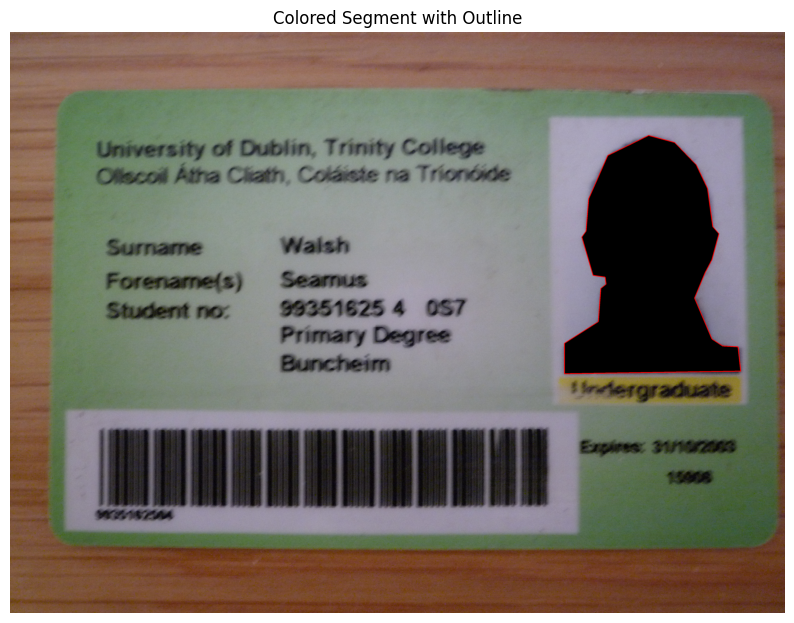

In [ ]:
first_attr = annotations_data["annotations"][image_id]["attributes"][0]
segmentation = first_attr["segmentation"]
color_segmented_area(image_path, segmentation)

In [ ]:
print("Image shape:", img.shape)
print("Mask unique values:", np.unique(mask))
print("Masked pixel count:", np.count_nonzero(mask))



Image shape: (3312, 4416, 3)
Mask unique values: [0 1]
Masked pixel count: 44088


# Object Detection

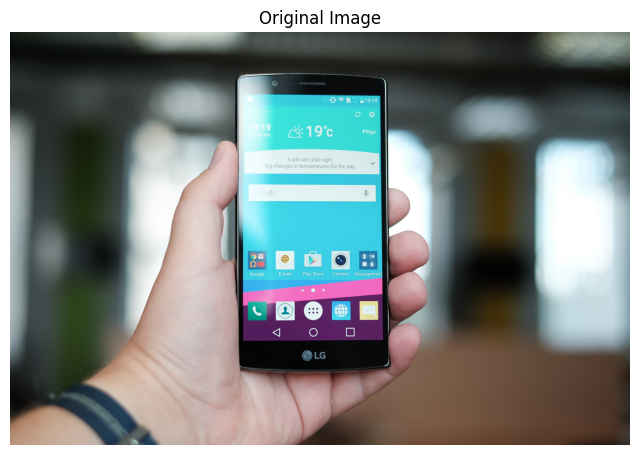

In [ ]:
import json
import cv2
import matplotlib.pyplot as plt

# Define paths
image_id = "2017_10624128"
image_path = f"/content/{image_id}.jpg"
annotation_path = f"/content/{image_id}.json"

# Load and display the image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original Image")
plt.show()



In [ ]:
# Load and print object detection annotation
with open(annotation_path, "r") as f:
    detection_data = json.load(f)

from pprint import pprint
print("Annotation Data:")
pprint(detection_data)

Annotation Data:
{'id': '2017_10624128',
 'image_path': 'images/val2017/2017_10624128.jpg',
 'labels': ['a75_address_current_partial', 'a82_date_time'],
 'openimages_id': 'feaca1b557b1200d',
 'source_url': 'https://c6.staticflickr.com/1/324/19102493598_0394747be3_o.jpg'}
